# Image Recognition & Segmentation

Two-stage pipeline that improves color extraction by first classifying product type, then applying type-conditional color extraction. Includes evaluation against ground truth and an active learning cycle to improve the classifier.

**Stage 1: Classifier:** ResNet-18 fine-tuned on seven container/presentation types: `bullet`, `liquid`, `closed`, `swatch`, `pencil`, `lips`, `unclassifiable`. `pencil` and `lips` were introduced in a later annotation round; `lips` (18 examples) is now the scarcer of the two after `pencil` grew to 28 in the pencil/crayon keyword-oversampling round. `unclassifiable` merges two dead-end cases -- a fully sealed container with no color visible, and a photo showing multiple products / a palette / not a single product shot -- since both get the same downstream treatment (no extraction).

**Stage 2: Segmenters:** U-Nets (ResNet-18 encoder, ImageNet pretrained) trained per class:
- `bullet` + `liquid` + `pencil` → `unet_segmenter.pth`
- `closed` (transparent containers) → `unet_segmenter_other.pth`
- `swatch` → `unet_swatch.pth`
- `lips` → `unet_lips.pth` -- warm-started from the combined segmenter like `closed` was; now has a real held-out validation split (18 examples, started at 3 with no validation possible at all)
- `unclassifiable` has no segmenter -- there's nothing to extract from either underlying case.

**Routing logic:**
- `bullet` / `liquid` / `pencil` → U-Net mask → median LAB from masked pixels
- `closed` → separate U-Net mask → dominant cluster LAB from masked pixels
- `swatch` → U-Net mask → median LAB from masked pixels
- `lips` → U-Net mask → median LAB from masked pixels
- `unclassifiable` → no extraction (trained class, not a confidence-threshold guess)
- confidence < 0.6 for any prediction → no extraction, same as `unclassifiable` -- a secondary safety net for images that don't even resemble the trained `unclassifiable` examples

**Evaluation:** Delta E CIE 2000 vs. ground-truth LAB per container type; five extraction strategies compared (mean, median, trimmed mean, dominant cluster, shadow-filtered) to select the best per type.

**Active learning:** classifier uncertainty is scored on out-of-training images; low-confidence predictions are exported as an annotation queue, corrected labels are merged back, and Stage 1 is fine-tuned on the expanded dataset. Section 7 does the same for segmentation masks, covering `pencil` and `lips`.

**Inputs:** `data/processed/annotations_combined.csv`, `data/img/annotation_sample/`, `data/img/annotation_sample_closed/`, `data/processed/project-4-at-2026-08-22-23-28-2ae685b5.json`

**Outputs:** `models/resnet18_classifier.pth`, `models/unet_segmenter.pth`, `models/unet_segmenter_other.pth`, `models/unet_swatch.pth`, `models/unet_lips.pth`, `models/resnet18_classifier_al.pth`, `data/annotations/labels.csv`, `data/annotations/masks/`, `data/annotations/active_learning_queue.csv`, `data/annotations/active_learning_seg_queue.csv`

In [1]:
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from skimage import color as skcolor
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

BASE = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, BASE)

DATA       = os.path.join(BASE, 'data', 'processed')
IMG        = os.path.join(BASE, 'data', 'img')
ANN_DIR    = os.path.join(BASE, 'data', 'annotations')
MASKS_DIR  = os.path.join(ANN_DIR, 'masks')
MODELS_DIR = os.path.join(BASE, 'models')
IMG_SAMPLE = os.path.join(IMG, 'annotation_sample')
IMG_CLOSED = os.path.join(IMG, 'annotation_sample_closed')
IMG_DIRS   = [IMG_SAMPLE, IMG_CLOSED]

os.makedirs(MASKS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEVICE}  |  seed: {SEED}')

device: mps  |  seed: 42


## 1. Data Preparation

In [2]:
CLASSES = ['bullet', 'closed', 'lips', 'liquid', 'pencil', 'swatch', 'unclassifiable']  # sorted alphabetically
CLF_THRESHOLD = 0.6  # below this confidence for ANY class → no extraction (secondary safety net)

df = pd.read_csv(os.path.join(DATA, 'annotations_combined.csv'))
print(df['label'].value_counts())
print(f'\n{len(df)} annotated images')

label
swatch            123
bullet             84
liquid             59
closed             39
pencil             28
unclassifiable     28
lips               18
Name: count, dtype: int64

379 annotated images


In [3]:
from label_studio_converter.brush import decode_rle as _ls_decode_rle

def find_image(img_name, img_dirs=IMG_DIRS):
    for d in img_dirs:
        p = os.path.join(d, img_name)
        if os.path.exists(p):
            return p
    return None

def decode_rle(rle, height, width):
    """Decode Label Studio brush RLE to a binary mask (H x W, uint8).
    Label Studio encodes brush strokes as RGBA; the mask region is the alpha channel (index 3).
    """
    flat = _ls_decode_rle(rle)           # → length h*w*4, row-major RGBA bytes
    rgba = flat.reshape(height, width, 4)
    return (rgba[:, :, 3] > 0).astype(np.uint8)

In [4]:
import re

def resolve_img_name(img_name):
    """Map a Label Studio img_name to the actual filename on disk.
    When two images shared a base filename, Label Studio appended _XXXXXXX (7 alphanumeric chars)
    before the extension. Strip the suffix to find the real file, but keep the original name for traceability.
    """
    if find_image(img_name) is not None:
        return img_name
    base = re.sub(r'_[A-Za-z0-9]{7}(\.jpg)$', r'\1', img_name)
    if base != img_name and find_image(base) is not None:
        return base
    return None  # unresolvable

df['img_name_disk'] = df['img_name'].apply(resolve_img_name)
found    = df['img_name_disk'].notna().sum()
not_found = df['img_name_disk'].isna().sum()
print(f'{found} images resolved to a file on disk, {not_found} unresolvable')
print(df[['img_name', 'img_name_disk']].head(3))

311 images resolved to a file on disk, 68 unresolvable
                                            img_name  \
0  lipstick__aboutface__paintit_matte_lip_color__...   
1  lipstick__anastasia_beverly_hills__liquid_lips...   
2  lipstick__anastasia_beverly_hills__liquid_lips...   

                                       img_name_disk  
0  lipstick__aboutface__paintit_matte_lip_color__...  
1  lipstick__anastasia_beverly_hills__liquid_lips...  
2  lipstick__anastasia_beverly_hills__liquid_lips...  


In [5]:
# Decode RLE masks from Label Studio JSON → save as PNG in data/annotations/masks/
with open(os.path.join(DATA, 'project-4-at-2026-08-22-23-28-2ae685b5.json')) as f:
    raw = json.load(f)

task_lookup = {}
for task in raw:
    img_name = os.path.basename(task['data']['image'])
    img_name = img_name.split('-', 1)[-1] if '-' in img_name else img_name
    ann = task['annotations'][0]
    if not ann['result']:
        continue
    task_lookup[img_name] = ann['result'][0]  # store full result entry (h/w are here, not in ['value'])

saved, skipped = 0, 0
for _, row in df.iterrows():
    stem = os.path.splitext(row['img_name'])[0]
    out_path = os.path.join(MASKS_DIR, stem + '.png')
    if row['img_name'] not in task_lookup:
        skipped += 1
        continue
    entry = task_lookup[row['img_name']]
    rle = entry['value'].get('rle', [])
    h   = entry.get('original_height', 0)
    w   = entry.get('original_width', 0)
    if not rle or not h or not w:
        skipped += 1
        continue
    mask = decode_rle(rle, h, w)
    Image.fromarray(mask * 255).save(out_path)
    saved += 1

print(f'Saved {saved} masks, skipped {skipped}')

Saved 379 masks, skipped 0


In [6]:
# Join with ground-truth LAB values and save data/annotations/labels.csv
products = pd.read_csv(os.path.join(DATA, 'products_with_images.csv'))
gt = products[products['ground_truth_CIELAB'].notna()][['img_name', 'ground_truth_CIELAB']].copy()

# Normalize GT img_names to .jpg — annotation_sample uses original_clean/ which converts everything to .jpg
gt['img_name_disk'] = gt['img_name'].apply(lambda n: os.path.splitext(n)[0] + '.jpg')

def parse_cielab(s):
    arr = np.fromstring(str(s).strip('[]'), sep=' ')
    return pd.Series({'true_L': arr[0], 'true_a': arr[1], 'true_b': arr[2]})

gt = gt.join(gt['ground_truth_CIELAB'].apply(parse_cielab)).drop(columns=['ground_truth_CIELAB', 'img_name'])

# Join on img_name_disk (resolved filename) so suffix-conflict rows match correctly
labels_df = df.merge(gt, on='img_name_disk', how='left')
labels_df['mask_path'] = labels_df['img_name'].apply(
    lambda n: os.path.join(MASKS_DIR, os.path.splitext(n)[0] + '.png')
)
labels_df.to_csv(os.path.join(ANN_DIR, 'labels.csv'), index=False)
print(labels_df[['img_name', 'img_name_disk', 'label', 'true_L']].head())
print(f'\n{labels_df["true_L"].notna().sum()} / {len(labels_df)} images have ground-truth LAB')


                                            img_name  \
0  lipstick__aboutface__paintit_matte_lip_color__...   
1  lipstick__anastasia_beverly_hills__liquid_lips...   
2  lipstick__anastasia_beverly_hills__liquid_lips...   
3  lipstick__anastasia_beverly_hills__matte_lipst...   
4  lipstick__anastasia_beverly_hills__matte_lipst...   

                                       img_name_disk   label     true_L  
0  lipstick__aboutface__paintit_matte_lip_color__...  swatch   2.677718  
1  lipstick__anastasia_beverly_hills__liquid_lips...  swatch  42.008854  
2  lipstick__anastasia_beverly_hills__liquid_lips...  liquid  27.463101  
3  lipstick__anastasia_beverly_hills__matte_lipst...  bullet  57.439487  
4  lipstick__anastasia_beverly_hills__matte_lipst...  swatch  63.296015  

178 / 379 images have ground-truth LAB


Class distribution is unbalanced: swatches make up ~32% of annotations. `lips` (18) is now the scarcest class overall -- the pencil/crayon keyword-oversampling round (Round 5) tripled `pencil` from 9 to 28, pushing it past `lips`, which slipped slightly (19 to 18) when one image was relabeled from `lips` to `pencil`.

Weighted cross-entropy loss in Stage 1 compensates for this imbalance, though with only 2-3 validation examples for `pencil`/`closed` the per-class validation metrics for those are noisy almost by definition.

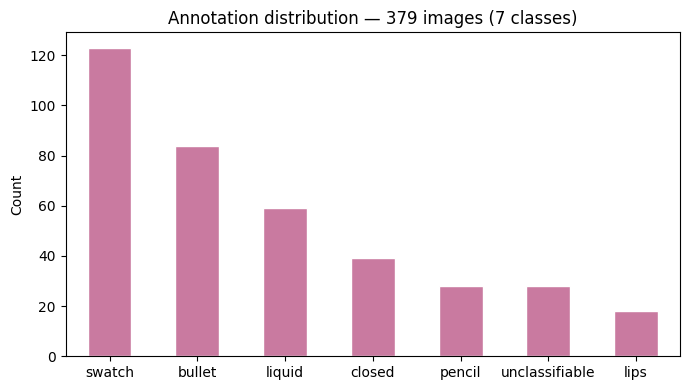

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
labels_df['label'].value_counts().plot(kind='bar', ax=ax, color='#c97aa0', edgecolor='white')
ax.set_title(f'Annotation distribution — {len(labels_df)} images ({len(CLASSES)} classes)')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

We fine-tune a ResNet-18 on the seven annotated container/presentation types (`bullet`, `liquid`, `closed`, `swatch`, `pencil`, `lips`, `unclassifiable`). Training uses two phases: first the backbone is frozen and only the classification head is trained (5 epochs), then the full network is fine-tuned at a lower learning rate (15 epochs). Weighted cross-entropy loss compensates for class imbalance -- `lips` (18) is now the scarcest, well below `pencil` (28), `closed` (39), or `swatch` (123).

**Handling out-of-distribution images:** `unclassifiable` is trained specifically to catch multiple patterns: a fully sealed container with nothing visible, and a photo showing multiple products, a palette, or otherwise not a single clean product shot. That's an explicit, trained catch — a real improvement over the original design, which relied purely on classifier *uncertainty* to catch these cases. Uncertainty isn't a reliable proxy for "doesn't belong to any trained class": a multi-product photo can easily contain something that looks enough like a `bullet` to get a confident, wrong prediction rather than a low-confidence one. The confidence threshold (`CLF_THRESHOLD = 0.6`) is kept as a secondary safety net for images that don't even resemble the `unclassifiable` training examples -- genuinely novel formats not yet seen at all. Both paths lead to the same outcome: no color extracted.

In [8]:
IMG_SIZE_CLS = 224

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_CLS, IMG_SIZE_CLS)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_CLS, IMG_SIZE_CLS)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class ProductDataset(Dataset):
    def __init__(self, df, transform):
        # drop rows where the image can't be found on disk
        self.df = df[df['img_name_disk'].notna()].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(find_image(row['img_name_disk'])).convert('RGB')
        return self.transform(img), CLASSES.index(row['label'])

In [9]:
def build_classifier(num_classes=len(CLASSES), pretrained=True):
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    m = models.resnet18(weights=weights)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

counts = labels_df['label'].value_counts()
total  = len(labels_df)
class_weights = torch.tensor(
    [total / (len(CLASSES) * counts[c]) for c in CLASSES], dtype=torch.float
)
print('Class weights:', {c: round(w, 3) for c, w in zip(CLASSES, class_weights.tolist())})

Class weights: {'bullet': 0.645, 'closed': 1.388, 'lips': 3.008, 'liquid': 0.918, 'pencil': 1.934, 'swatch': 0.44, 'unclassifiable': 1.934}


In [10]:
def run_epoch(model, loader, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            n          += len(y)
    return total_loss / n, correct / n

def train_classifier(model, train_ds, val_ds, device, ckpt_path):
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=32, num_workers=0)

    # Phase 1: freeze backbone
    for p in model.parameters():
        p.requires_grad = False
    for p in model.fc.parameters():
        p.requires_grad = True
    opt = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
    print('Phase 1 — head only (5 epochs)')
    for epoch in range(5):
        _, tr_acc = run_epoch(model, train_loader, criterion, opt, device)
        _, va_acc = run_epoch(model, val_loader,   criterion, opt, device, train=False)
        print(f'  {epoch+1:2d}: train={tr_acc:.3f}  val={va_acc:.3f}')

    # Phase 2: fine-tune all
    for p in model.parameters():
        p.requires_grad = True
    opt = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.1)
    best_val_acc = 0.0
    print('Phase 2 — fine-tune all (15 epochs)')
    for epoch in range(15):
        _, tr_acc = run_epoch(model, train_loader, criterion, opt, device)
        _, va_acc = run_epoch(model, val_loader,   criterion, opt, device, train=False)
        scheduler.step()
        print(f'  {epoch+1:2d}: train={tr_acc:.3f}  val={va_acc:.3f}')
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            torch.save({'model_state_dict': model.state_dict(), 'classes': CLASSES}, ckpt_path)
    print(f'\nBest val acc: {best_val_acc:.3f}  →  {ckpt_path}')

In [11]:
# Split strategy:
# - annotation_sample_closed images (40 oversampled closed class) → always in train
# - everything else → random 80/20 stratified split
ann_closed_files = set(os.listdir(IMG_CLOSED))

force_train = labels_df[labels_df['img_name_disk'].isin(ann_closed_files)]
to_split    = labels_df[~labels_df['img_name_disk'].isin(ann_closed_files) & labels_df['img_name_disk'].notna()]

train_rest, val_df = train_test_split(
    to_split, test_size=0.2, stratify=to_split['label'], random_state=42
)
train_df = pd.concat([force_train, train_rest]).reset_index(drop=True)

print(f'Train: {len(train_df)}  ({len(force_train)} forced closed-addition + {len(train_rest)} random)')
print(f'Val:   {len(val_df)}')
print('\nTrain label distribution:')
print(train_df['label'].value_counts().to_string())
print('\nVal label distribution:')
print(val_df['label'].value_counts().to_string())

clf = build_classifier(num_classes=len(CLASSES)).to(DEVICE)
clf_ckpt = os.path.join(MODELS_DIR, 'resnet18_classifier.pth')
train_classifier(clf, ProductDataset(train_df, train_tf), ProductDataset(val_df, val_tf), DEVICE, clf_ckpt)

Train: 252  (20 forced closed-addition + 232 random)
Val:   59

Train label distribution:
label
swatch            86
bullet            58
liquid            40
pencil            22
closed            19
unclassifiable    14
lips              13

Val label distribution:
label
swatch            21
bullet            15
liquid             9
pencil             5
unclassifiable     4
lips               3
closed             2


Phase 1 — head only (5 epochs)


   1: train=0.214  val=0.339


   2: train=0.484  val=0.593


   3: train=0.710  val=0.780


...

  11: train=1.000  val=0.949


  12: train=1.000  val=0.949


  13: train=1.000  val=0.949


  14: train=1.000  val=0.949


  15: train=1.000  val=0.949

Best val acc: 0.949  →  /Users/connie/dev/lipstick_color_extraction/models/resnet18_classifier.pth


                precision    recall  f1-score   support

        bullet       1.00      0.87      0.93        15
        closed       0.50      0.50      0.50         2
          lips       1.00      1.00      1.00         3
        liquid       1.00      1.00      1.00         9
        pencil       0.83      1.00      0.91         5
        swatch       1.00      1.00      1.00        21
unclassifiable       0.80      1.00      0.89         4

      accuracy                           0.95        59
     macro avg       0.88      0.91      0.89        59
  weighted avg       0.96      0.95      0.95        59



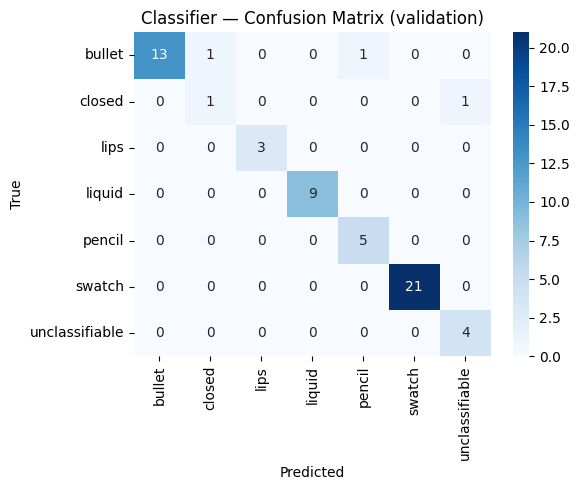

In [12]:
# Load best checkpoint and evaluate on validation set
ckpt = torch.load(clf_ckpt, map_location=DEVICE)
clf.load_state_dict(ckpt['model_state_dict'])
clf.eval()

preds, targets = [], []
with torch.no_grad():
    for x, y in DataLoader(ProductDataset(val_df, val_tf), batch_size=32):
        preds.extend(clf(x.to(DEVICE)).argmax(1).cpu().tolist())
        targets.extend(y.tolist())

print(classification_report(targets, preds, target_names=CLASSES))

cm = confusion_matrix(targets, preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES,
            cmap='Blues', ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Classifier — Confusion Matrix (validation)')
plt.tight_layout(); plt.show()

**Confidence threshold check:** `CLF_THRESHOLD = 0.6` is now a secondary safety net -- `unclassifiable` is a trained class, so most dead-end images should already be routed there directly by the classifier rather than caught by low confidence. The cell below scores all annotated images and shows the ones that would still be caught by this threshold gate -- a face-value sanity check that it's not silently swallowing valid images from the six real product classes.

3 image(s) fall below CLF_THRESHOLD=0.6


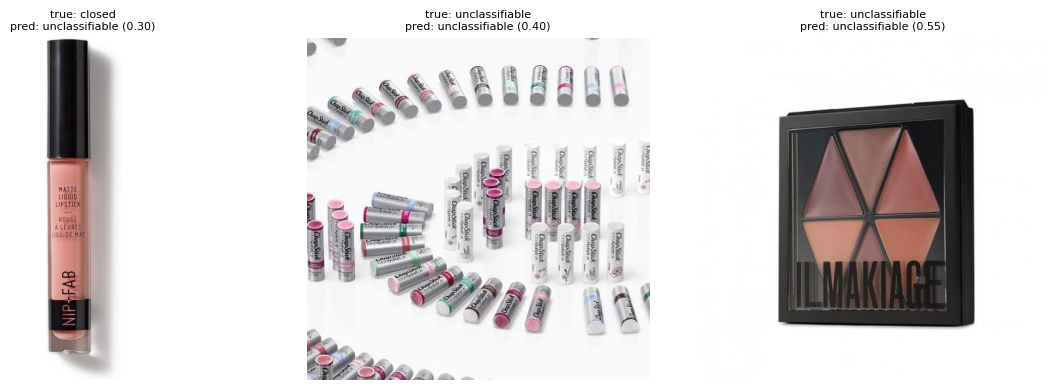

In [13]:
clf.eval()
low_conf = []
for _, row in labels_df.iterrows():
    if pd.isna(row['img_name_disk']):
        continue
    img_path = find_image(row['img_name_disk'])
    if img_path is None:
        continue
    img = Image.open(img_path).convert('RGB')
    with torch.no_grad():
        probs = torch.softmax(clf(val_tf(img).unsqueeze(0).to(DEVICE)), dim=1).squeeze().cpu().numpy()
    conf = float(probs.max())
    if conf < CLF_THRESHOLD:
        low_conf.append({
            'img_path':   img_path,
            'true_label': row['label'],
            'pred_label': CLASSES[probs.argmax()],
            'confidence': conf,
        })

print(f'{len(low_conf)} image(s) fall below CLF_THRESHOLD={CLF_THRESHOLD}')

if low_conf:
    ncols = min(4, len(low_conf))
    nrows = (len(low_conf) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, item in zip(axes, low_conf):
        ax.imshow(Image.open(item['img_path']).convert('RGB'))
        ax.set_title(
            f"true: {item['true_label']}\npred: {item['pred_label']} ({item['confidence']:.2f})",
            fontsize=8
        )
        ax.axis('off')
    for ax in axes[len(low_conf):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


## 3. Stage 2: Color Region Segmenter

Once the classifier assigns a product type, a segmentation model isolates the color-bearing region of the image. We use a U-Net with a ResNet-18 encoder pretrained on ImageNet: the encoder extracts features and the decoder produces a binary mask (1 = color region, 0 = background). All models are trained at 256×256 and evaluated with IoU (Intersection over Union) on a held-out validation split.

Different product types require different segmenters because their color regions look nothing alike — a bullet tip, a liquid applicator wand, a closed container's visible color through packaging, and a flat swatch each present a distinct segmentation problem. Stage 2a trains a combined segmenter for `bullet`, `liquid`, and `pencil` (a pen/crayon-style applicator tip is visually closer to a bullet tip than to anything else, and it now has enough data (28 images) that it could arguably justify its own model, but stays combined for now since it's still well below `closed` (39) or `bullet`/`liquid` counts). Stage 2b covers `closed` containers; Stage 2c tests whether splitting `bullet` and `liquid` into separate models improves on the combined approach; Stage 2d adds a segmenter for `swatch`; Stage 2e adds a segmenter for `lips` -- originally a 3-example bootstrap with no validation possible at all, now retrained with a real held-out split now that it has 18 examples.

### Stage 2a: Color Region Segmenter for `bullet`, `liquid`, and `pencil`

In [14]:
IMG_SIZE_SEG = 256

seg_img_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_SEG, IMG_SIZE_SEG)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
seg_mask_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_SEG, IMG_SIZE_SEG),
                      interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor(),
])

SEG_CLASSES = {'bullet', 'liquid', 'pencil'}

class SegDataset(Dataset):
    def __init__(self, df):
        self.df = df[df['label'].isin(SEG_CLASSES) & df['img_name_disk'].notna()].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = Image.open(find_image(row['img_name_disk'])).convert('RGB')
        mp   = row['mask_path']
        mask = Image.open(mp).convert('L') if os.path.exists(mp) else Image.new('L', img.size, 0)
        return seg_img_tf(img), (seg_mask_tf(mask) > 0.5).float()

In [15]:
def build_segmenter():
    return smp.Unet(
        encoder_name='resnet18',
        encoder_weights='imagenet',
        in_channels=3,
        classes=1,
    )

def batch_iou(logits, masks, threshold=0.5):
    pred = (torch.sigmoid(logits) > threshold).float()
    inter = (pred * masks).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - inter
    return (inter / (union + 1e-6)).mean().item()

In [16]:
seg_train_df, seg_val_df = train_test_split(
    labels_df[labels_df['label'].isin(SEG_CLASSES)],
    test_size=0.2, stratify=labels_df[labels_df['label'].isin(SEG_CLASSES)]['label'],
    random_state=42
)
seg_train_ds = SegDataset(seg_train_df)
seg_val_ds   = SegDataset(seg_val_df)
print(f'Seg train: {len(seg_train_ds)}  val: {len(seg_val_ds)}')

seg = build_segmenter().to(DEVICE)
criterion_seg = nn.BCEWithLogitsLoss()
opt_seg       = torch.optim.Adam(seg.parameters(), lr=1e-4)
seg_ckpt      = os.path.join(MODELS_DIR, 'unet_segmenter.pth')

best_iou = 0.0
for epoch in range(20):
    seg.train()
    for imgs, masks in DataLoader(seg_train_ds, batch_size=16, shuffle=True, num_workers=0):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        loss = criterion_seg(seg(imgs), masks)
        opt_seg.zero_grad(); loss.backward(); opt_seg.step()

    seg.eval()
    val_ious = []
    with torch.no_grad():
        for imgs, masks in DataLoader(seg_val_ds, batch_size=16, num_workers=0):
            val_ious.append(batch_iou(seg(imgs.to(DEVICE)), masks.to(DEVICE)))
    mean_iou = np.mean(val_ious)
    print(f'epoch {epoch+1:2d}: IoU={mean_iou:.4f}')
    if mean_iou > best_iou:
        best_iou = mean_iou
        torch.save({'model_state_dict': seg.state_dict()}, seg_ckpt)

print(f'\nBest IoU: {best_iou:.4f}  →  {seg_ckpt}')


Seg train: 120  val: 29


epoch  1: IoU=0.0270


epoch  2: IoU=0.0533


epoch  3: IoU=0.1224


epoch  4: IoU=0.2665


...

epoch 16: IoU=0.6599


epoch 17: IoU=0.6522


epoch 18: IoU=0.6236


epoch 19: IoU=0.6747


epoch 20: IoU=0.6668

Best IoU: 0.6760  →  /Users/connie/dev/lipstick_color_extraction/models/unet_segmenter.pth


**Note: scheduler experiment (worse, not used):** Adding `ReduceLROnPlateau` (factor=0.3, patience=5) and extending to 30 epochs produced lower validation IoU than the simple 20-epoch fixed-LR run above. The bottleneck is data size (74 training images), not the learning rate schedule. The path to better segmentation is more annotated images, not longer training.

Visual check on a sample of 4 validation images: original image, hand-drawn Label Studio mask (ground truth), and U-Net prediction side by side. Confirms mask alignment before using predictions for color extraction.

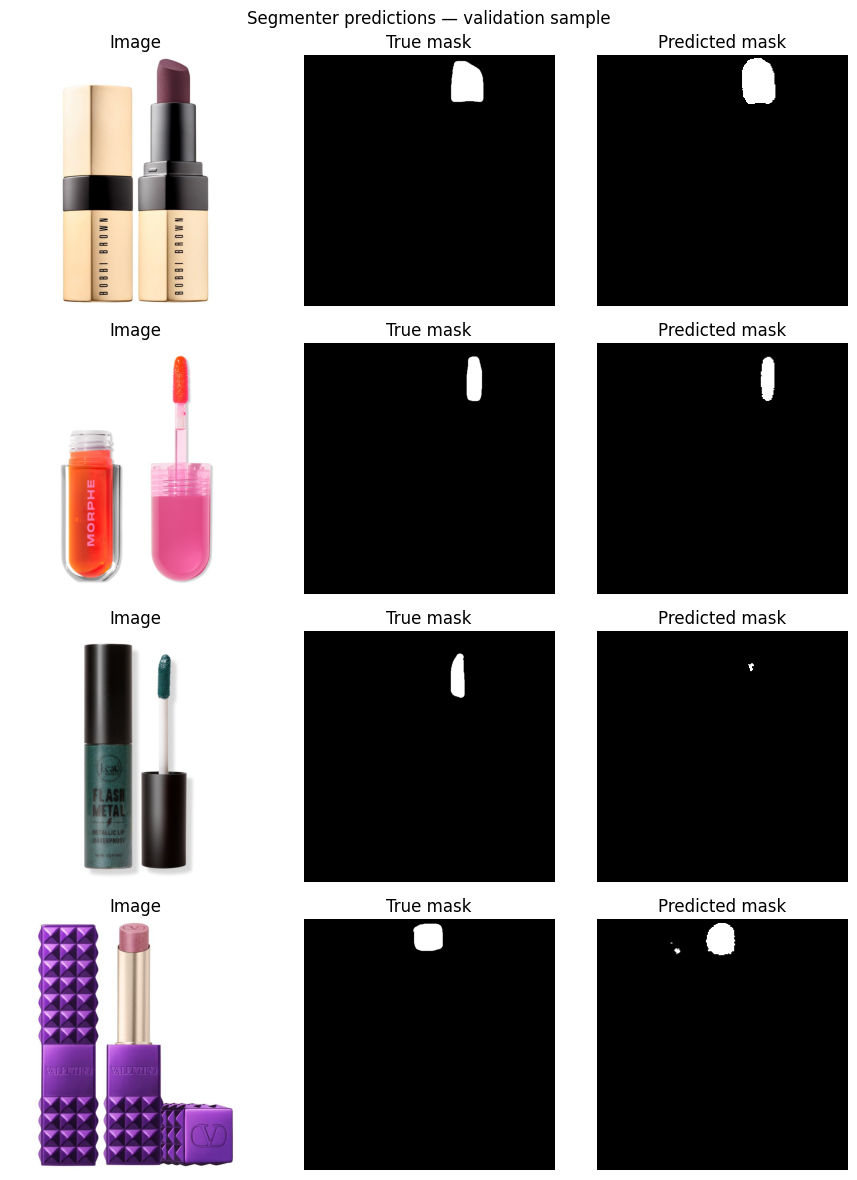

In [17]:
# Visualise a few val predictions
ckpt_seg = torch.load(seg_ckpt, map_location=DEVICE)
seg.load_state_dict(ckpt_seg['model_state_dict'])
seg.eval()

sample = seg_val_df.dropna(subset=['img_name_disk']).head(4).reset_index(drop=True)
fig, axes = plt.subplots(4, 3, figsize=(9, 12))
for i, row in sample.iterrows():
    img_path = find_image(row['img_name_disk'])
    img = Image.open(img_path).convert('RGB')
    x   = seg_img_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_mask = (torch.sigmoid(seg(x)) > 0.5).squeeze().cpu().numpy()
    true_mask = np.array(Image.open(row['mask_path']).convert('L')) if os.path.exists(row['mask_path']) else np.zeros((img.size[1], img.size[0]))
    axes[i, 0].imshow(img); axes[i, 0].set_title('Image')
    axes[i, 1].imshow(true_mask, cmap='gray'); axes[i, 1].set_title('True mask')
    axes[i, 2].imshow(pred_mask, cmap='gray'); axes[i, 2].set_title('Predicted mask')
    for ax in axes[i]: ax.axis('off')
plt.suptitle('Segmenter predictions — validation sample')
plt.tight_layout()
plt.show()

In [18]:
# Shared segmentation helpers, used by the augmentation experiment below and by
# Stages 2b-2d: a dataset that accepts any label subset (with optional
# synchronized image+mask augmentation) and a generic U-Net training loop.
import random

class SegDatasetAny(Dataset):
    """Like SegDataset but accepts any label subset, with optional synchronized augmentation."""
    def __init__(self, df, augment=False):
        self.df      = df[df['img_name_disk'].notna()].reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = Image.open(find_image(row['img_name_disk'])).convert('RGB')
        mp   = row['mask_path']
        mask = Image.open(mp).convert('L') if os.path.exists(mp) else Image.new('L', img.size, 0)

        if self.augment:
            if random.random() > 0.5:
                img  = img.transpose(Image.FLIP_LEFT_RIGHT)
                mask = mask.transpose(Image.FLIP_LEFT_RIGHT)
            if random.random() > 0.5:
                img  = img.transpose(Image.FLIP_TOP_BOTTOM)
                mask = mask.transpose(Image.FLIP_TOP_BOTTOM)
            angle = random.uniform(-15, 15)
            img  = img.rotate(angle)
            mask = mask.rotate(angle)

        return seg_img_tf(img), (seg_mask_tf(mask) > 0.5).float()

def train_seg_model(train_df, val_df, ckpt_path, n_epochs=20, augment=False):
    train_ds = SegDatasetAny(train_df, augment=augment)
    val_ds   = SegDatasetAny(val_df,   augment=False)
    model    = build_segmenter().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    opt       = torch.optim.Adam(model.parameters(), lr=1e-4)
    best_iou  = 0.0
    for epoch in range(n_epochs):
        model.train()
        for imgs, masks in DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            loss = criterion(model(imgs), masks)
            opt.zero_grad(); loss.backward(); opt.step()
        model.eval()
        val_ious = []
        with torch.no_grad():
            for imgs, masks in DataLoader(val_ds, batch_size=16, num_workers=0):
                val_ious.append(batch_iou(model(imgs.to(DEVICE)), masks.to(DEVICE)))
        mean_iou = np.mean(val_ious)
        print(f'  epoch {epoch+1:2d}: IoU={mean_iou:.4f}')
        if mean_iou > best_iou:
            best_iou = mean_iou
            torch.save({'model_state_dict': model.state_dict()}, ckpt_path)
    print(f'Best IoU: {best_iou:.4f}  →  {ckpt_path}')
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE)['model_state_dict'])
    model.eval()
    return model, best_iou

**Augmentation experiment:** The baseline above (Stage 2a, now trained on a larger pool that includes the pencil/crayon oversampling batch -- 149 images vs. 105 before) reached IoU 0.6760. Re-running with synchronized augmentation (random horizontal flips + small rotations) and 60 epochs reached IoU 0.7051 -- again a real improvement over baseline, consistent with earlier rounds. (Note: Python's `random` module isn't seeded like `numpy`/`torch` are, so the augmented run's exact IoU drifts between re-runs of this notebook -- across rounds it has landed anywhere from ~0.66 to ~0.77 for the baseline and ~0.70 to ~0.77 for the augmented version. The qualitative conclusion, augmentation helps, has held every time so far.)

**Not yet adopted downstream:** routing, the strategy comparison, and the end-to-end evaluation below still use the non-augmented `seg` checkpoint (`unet_segmenter.pth`), matching the original Stage 2a design. Given the result flipped, switching production to `unet_seg_augmented.pth` is worth revisiting, but that's a separate decision from the class-taxonomy change this notebook update was about.

In [19]:
seg_aug_ckpt = os.path.join(MODELS_DIR, 'unet_seg_augmented.pth')
seg_aug, iou_aug = train_seg_model(
    seg_train_df, seg_val_df, seg_aug_ckpt, n_epochs=60, augment=True
)
print(f'Baseline IoU: {best_iou:.4f}  →  Augmented IoU: {iou_aug:.4f}')

  epoch  1: IoU=0.0276


  epoch  2: IoU=0.0415


  epoch  3: IoU=0.0474


  epoch  4: IoU=0.0208


  epoch  5: IoU=0.0172


...

  epoch 56: IoU=0.6652


  epoch 57: IoU=0.6966


  epoch 58: IoU=0.6962


  epoch 59: IoU=0.7051


  epoch 60: IoU=0.6821
Best IoU: 0.7051  →  /Users/connie/dev/lipstick_color_extraction/models/unet_seg_augmented.pth
Baseline IoU: 0.6760  →  Augmented IoU: 0.7051


### Stage 2b: Color Region Segmenter for `closed` (Transparent Containers)

`closed` images (transparent containers) have hand-drawn masks highlighting the visible color through the packaging: the same annotation format as bullet/liquid. A separate U-Net is trained on these images so color can be extracted the same way as the other classes.

Same architecture and training procedure as Stage 2a; saved to `models/unet_segmenter_other.pth`.

In [20]:
other_df = labels_df[labels_df['label'] == 'closed'].reset_index(drop=True)
seg_other_train_df, seg_other_val_df = train_test_split(
    other_df, test_size=0.2, random_state=42
)
seg_other_train_ds = SegDatasetAny(seg_other_train_df, augment=True)
seg_other_val_ds   = SegDatasetAny(seg_other_val_df,   augment=False)
print(f'Other seg — train: {len(seg_other_train_ds)}  val: {len(seg_other_val_ds)}')

# Warm-start from bullet/liquid segmenter — encoder + decoder already tuned to lipstick images
seg_other = build_segmenter().to(DEVICE)
seg_other.load_state_dict(torch.load(seg_ckpt, map_location=DEVICE)['model_state_dict'])
print('Warm-started from unet_segmenter.pth')

crit_seg_other = nn.BCEWithLogitsLoss()
opt_seg_other  = torch.optim.Adam(seg_other.parameters(), lr=1e-4)
seg_other_ckpt = os.path.join(MODELS_DIR, 'unet_segmenter_other.pth')

best_iou_other = 0.0
for epoch in range(20):
    seg_other.train()
    for imgs, masks in DataLoader(seg_other_train_ds, batch_size=16, shuffle=True, num_workers=0):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        loss = crit_seg_other(seg_other(imgs), masks)
        opt_seg_other.zero_grad(); loss.backward(); opt_seg_other.step()

    seg_other.eval()
    val_ious = []
    with torch.no_grad():
        for imgs, masks in DataLoader(seg_other_val_ds, batch_size=16, num_workers=0):
            val_ious.append(batch_iou(seg_other(imgs.to(DEVICE)), masks.to(DEVICE)))
    mean_iou = np.mean(val_ious)
    print(f'epoch {epoch+1:2d}: IoU={mean_iou:.4f}')
    if mean_iou > best_iou_other:
        best_iou_other = mean_iou
        torch.save({'model_state_dict': seg_other.state_dict()}, seg_other_ckpt)

print(f'\nBest IoU: {best_iou_other:.4f}  →  {seg_other_ckpt}')

ckpt_seg_other = torch.load(seg_other_ckpt, map_location=DEVICE)
seg_other.load_state_dict(ckpt_seg_other['model_state_dict'])
seg_other.eval()
print('seg_other loaded from best checkpoint')

Other seg — train: 18  val: 3


Warm-started from unet_segmenter.pth


epoch  1: IoU=0.0009


epoch  2: IoU=0.2529


epoch  3: IoU=0.4554


...

epoch 16: IoU=0.7458


epoch 17: IoU=0.7368


epoch 18: IoU=0.7371


epoch 19: IoU=0.7262


epoch 20: IoU=0.7549

Best IoU: 0.7549  →  /Users/connie/dev/lipstick_color_extraction/models/unet_segmenter_other.pth
seg_other loaded from best checkpoint


Initial training on `closed` images (ImageNet weights, no augmentation) produced loose, imprecise masks: the model found the general region but failed to follow the color boundary tightly. Two changes improved this:

1. **Warm start from `unet_segmenter.pth`**: instead of starting from generic ImageNet weights, the model is initialized with the bullet/liquid segmenter's weights. Both encoder and decoder have already learned what a lipstick color-region mask looks like, giving a much better starting point.
2. **Synchronized augmentation**: horizontal flip, vertical flip, and ±15° rotation are applied identically to the image and mask during training. With only 18 training images, this significantly increases the effective diversity seen by the model.

The validation sample below shows the predicted mask aligning tightly with the ground-truth mask after these changes.

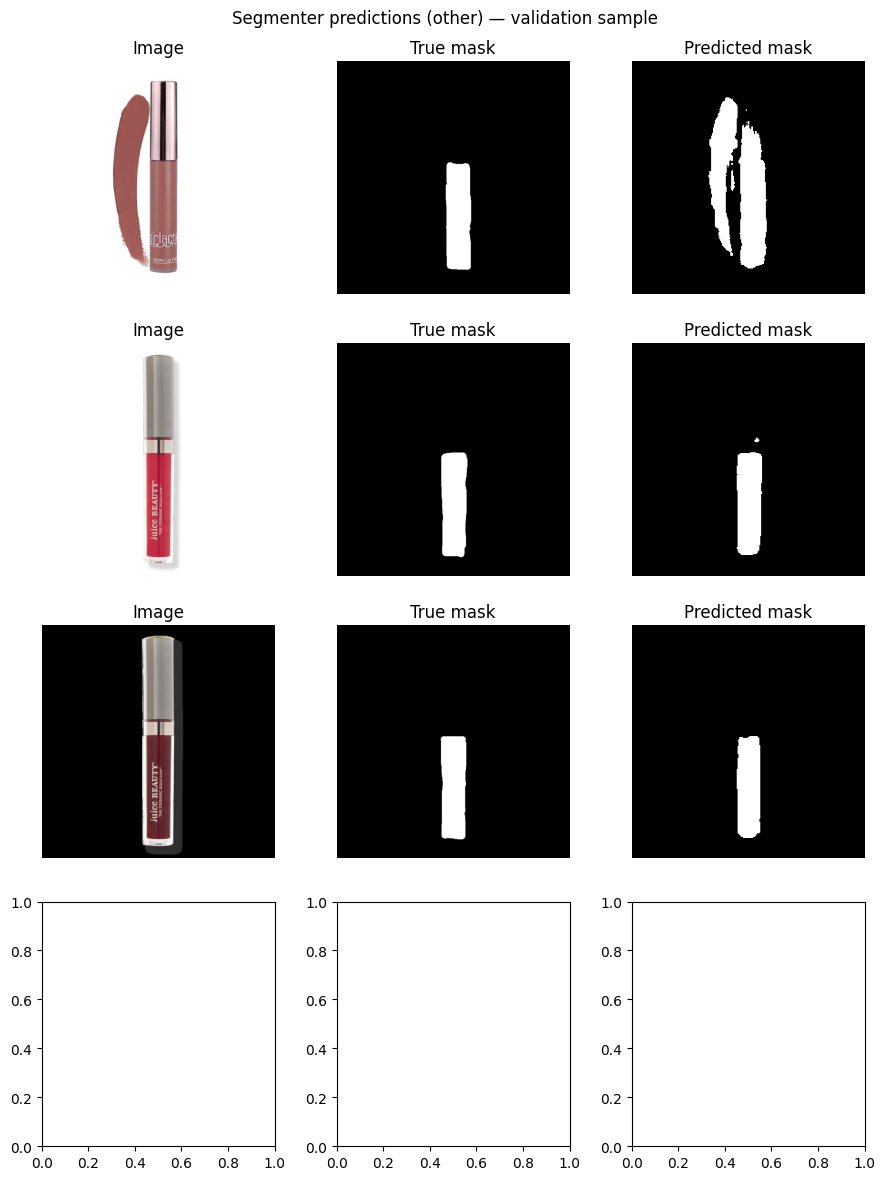

In [21]:
sample_other = seg_other_val_df.dropna(subset=['img_name_disk']).head(4).reset_index(drop=True)
fig, axes = plt.subplots(4, 3, figsize=(9, 12))
for i, row in sample_other.iterrows():
    img_path = find_image(row['img_name_disk'])
    img = Image.open(img_path).convert('RGB')
    x   = seg_img_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_mask = (torch.sigmoid(seg_other(x)) > 0.5).squeeze().cpu().numpy()
    true_mask = np.array(Image.open(row['mask_path']).convert('L')) if os.path.exists(row['mask_path']) else np.zeros((img.size[1], img.size[0]))
    axes[i, 0].imshow(img); axes[i, 0].set_title('Image')
    axes[i, 1].imshow(true_mask, cmap='gray'); axes[i, 1].set_title('True mask')
    axes[i, 2].imshow(pred_mask, cmap='gray'); axes[i, 2].set_title('Predicted mask')
    for ax in axes[i]: ax.axis('off')
plt.suptitle('Segmenter predictions (other) — validation sample')
plt.tight_layout()
plt.show()

### Stage 2c: Separate Segmenters for `bullet` vs `liquid`

Two paths for segmenting bullet and liquid lipsticks:

- **Combined (Stage 2a):** One U-Net trained on all `bullet` + `liquid` + `pencil` images (149 total, 120 train). More training data, simpler to maintain. Risk: the model must learn several visually distinct mask patterns simultaneously — an extended bullet tip, a doe-foot applicator wand, a pencil tip.
- **Separate (this section):** One U-Net per type, `bullet` vs `liquid` only (58 bullet train, 39 liquid train; `pencil` now has 27 examples -- enough that it could be tested separately, but isn't here since this comparison predates that growth and the conclusion below doesn't depend on it). Each model only sees one pattern, which may produce tighter masks. Trade-off: fewer training examples each.

The cells below train two separate models and compare their validation IoU against the combined model to see which approach generalises better.

In [22]:
bullet_df = labels_df[(labels_df['label'] == 'bullet') & labels_df['img_name_disk'].notna()]
liquid_df = labels_df[(labels_df['label'] == 'liquid') & labels_df['img_name_disk'].notna()]

bullet_train_df, bullet_val_df = train_test_split(bullet_df, test_size=0.2, random_state=42)
liquid_train_df, liquid_val_df = train_test_split(liquid_df, test_size=0.2, random_state=42)

print(f'Bullet — train: {len(bullet_train_df)}  val: {len(bullet_val_df)}')
print(f'Liquid — train: {len(liquid_train_df)}  val: {len(liquid_val_df)}')

bullet_ckpt = os.path.join(MODELS_DIR, 'unet_bullet.pth')
liquid_ckpt = os.path.join(MODELS_DIR, 'unet_liquid.pth')

print('Training bullet segmenter...')
seg_bullet, iou_bullet = train_seg_model(bullet_train_df, bullet_val_df, bullet_ckpt)

print('\nTraining liquid segmenter...')
seg_liquid, iou_liquid = train_seg_model(liquid_train_df, liquid_val_df, liquid_ckpt)


Bullet — train: 58  val: 15
Liquid — train: 39  val: 10
Training bullet segmenter...


  epoch  1: IoU=0.0506


  epoch  2: IoU=0.0635


  epoch  3: IoU=0.0746


  epoch  4: IoU=0.0763


...

  epoch 16: IoU=0.0856


  epoch 17: IoU=0.1033


  epoch 18: IoU=0.1189


  epoch 19: IoU=0.1315


  epoch 20: IoU=0.1305
Best IoU: 0.1315  →  /Users/connie/dev/lipstick_color_extraction/models/unet_liquid.pth


In [23]:
def eval_iou(model, df):
    ds = SegDatasetAny(df)
    model.eval()
    ious = []
    with torch.no_grad():
        for imgs, masks in DataLoader(ds, batch_size=16, num_workers=0):
            ious.append(batch_iou(model(imgs.to(DEVICE)), masks.to(DEVICE)))
    return np.mean(ious)

iou_combined_bullet = eval_iou(seg, bullet_val_df)
iou_combined_liquid = eval_iou(seg, liquid_val_df)
iou_combined_all    = eval_iou(seg, pd.concat([bullet_val_df, liquid_val_df]))

print('Validation IoU — combined vs separate segmenters\n')
print(f'{"":20} {"combined":>10} {"separate":>10}')
print(f'{"bullet":20} {iou_combined_bullet:>10.4f} {iou_bullet:>10.4f}')
print(f'{"liquid":20} {iou_combined_liquid:>10.4f} {iou_liquid:>10.4f}')
print(f'{"overall":20} {iou_combined_all:>10.4f} {(iou_bullet + iou_liquid) / 2:>10.4f}')

Validation IoU — combined vs separate segmenters

                       combined   separate
bullet                   0.8346     0.6002
liquid                   0.6865     0.1315
overall                  0.7726     0.3658


Splitting into separate models still hurt performance -- combined overall IoU 0.77 vs. separate 0.37 this run. The liquid segmenter alone collapsed (0.13 IoU standalone, vs. the combined model's 0.69 on the same images) and the bullet segmenter alone (0.60) trails the combined model's 0.83 by a similar margin. The exact numbers drift between re-runs -- both from the unseeded augmentation randomness noted in Stage 2a and, this round, from a genuinely larger `pencil` pool shifting the combined model's training -- but the qualitative conclusion has held every round: the combined model's advantage isn't just about having more data in aggregate, but also that seeing multiple mask patterns together helps the model learn a more robust "foreground lipstick vs background" representation. At this dataset size, data volume still matters more than pattern specialization, so the combined segmenter from Stage 2a is what gets used downstream.

### Stage 2d: Color Region Segmenter for `swatch`

It is unclear whether swatches require full segmentation or whether a simpler approach — such as filtering pixels by lightness threshold — would be sufficient for accurate color extraction. To establish a benchmark and keep the pipeline consistent across product types, we train a U-Net segmenter on the 107 annotated swatch images using the same architecture as Stage 2a.

**Improving segmentation quality:** An initial run without augmentation reached IoU 0.9049 at epoch 20. To push further, we added synchronized augmentation (random horizontal flips and small rotations applied identically to the image and mask) and extended training to 40 epochs. This brought IoU to **0.9204** (varies a couple points run to run, see the augmentation note in Stage 2a) — augmentation helped the model generalise across the varied backgrounds and orientations common in swatch photos.

In [24]:
swatch_df = labels_df[(labels_df['label'] == 'swatch') & labels_df['img_name_disk'].notna()]
swatch_train_df, swatch_val_df = train_test_split(swatch_df, test_size=0.2, random_state=42)
print(f'Swatch seg — train: {len(swatch_train_df)}  val: {len(swatch_val_df)}')

swatch_ckpt = os.path.join(MODELS_DIR, 'unet_swatch.pth')
seg_swatch, iou_swatch = train_seg_model(
    swatch_train_df, swatch_val_df, swatch_ckpt, n_epochs=40, augment=True
)


Swatch seg — train: 85  val: 22


  epoch  1: IoU=0.1997


  epoch  2: IoU=0.2530


  epoch  3: IoU=0.3932


  epoch  4: IoU=0.5169


...

  epoch 36: IoU=0.9169


  epoch 37: IoU=0.9193


  epoch 38: IoU=0.9187


  epoch 39: IoU=0.9186


  epoch 40: IoU=0.9183
Best IoU: 0.9204  →  /Users/connie/dev/lipstick_color_extraction/models/unet_swatch.pth


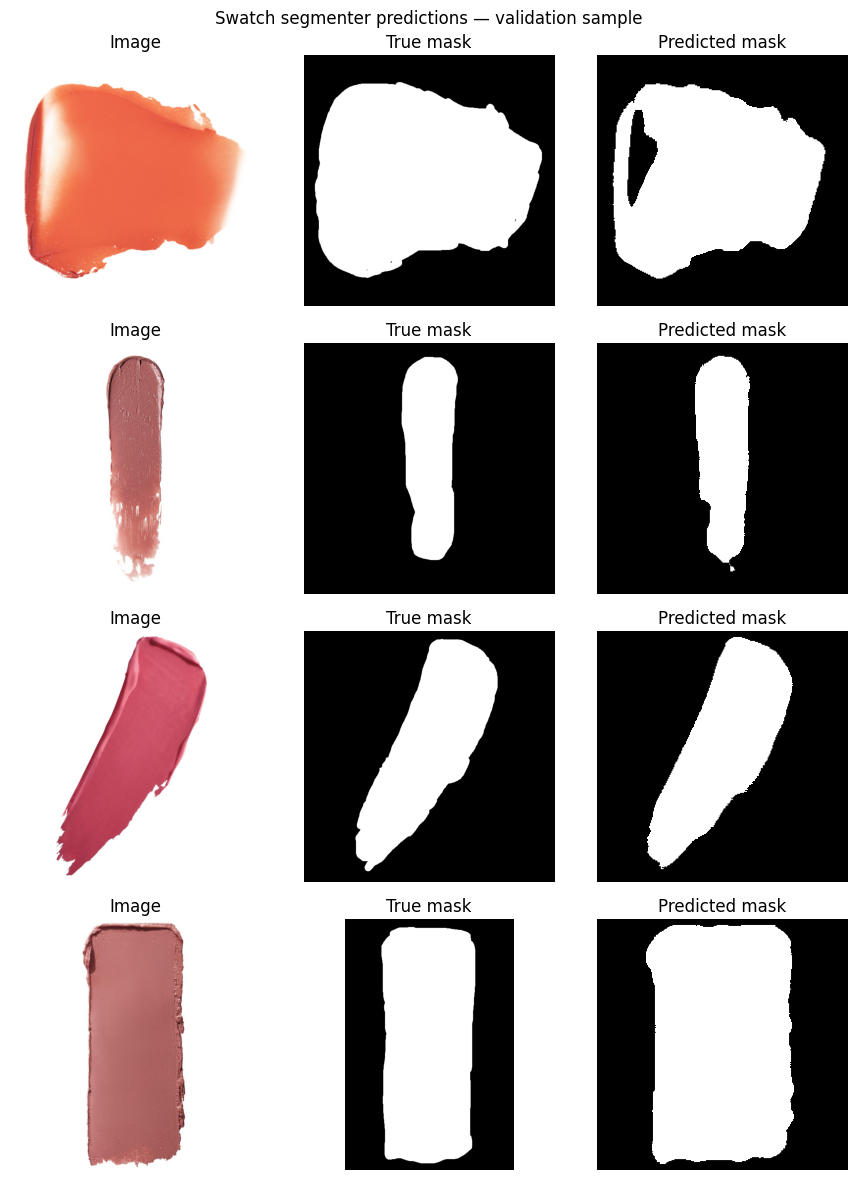

In [25]:
sample_swatch = swatch_val_df.dropna(subset=['img_name_disk']).head(4).reset_index(drop=True)
fig, axes = plt.subplots(4, 3, figsize=(9, 12))
for i, row in sample_swatch.iterrows():
    img = Image.open(find_image(row['img_name_disk'])).convert('RGB')
    x   = seg_img_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_mask = (torch.sigmoid(seg_swatch(x)) > 0.5).squeeze().cpu().numpy()
    true_mask = np.array(Image.open(row['mask_path']).convert('L')) if os.path.exists(row['mask_path']) else np.zeros((img.size[1], img.size[0]))
    axes[i, 0].imshow(img); axes[i, 0].set_title('Image')
    axes[i, 1].imshow(true_mask, cmap='gray'); axes[i, 1].set_title('True mask')
    axes[i, 2].imshow(pred_mask, cmap='gray'); axes[i, 2].set_title('Predicted mask')
    for ax in axes[i]: ax.axis('off')
plt.suptitle('Swatch segmenter predictions — validation sample')
plt.tight_layout()
plt.show()

### Stage 2e: Color Region Segmenter for `lips`

`lips` started Round 3 with 3 examples -- too few for any train/val split, so the first version of this model force-trained on all 3 with no way to measure real quality. Round 4's oversampling brought it to 19 labeled; Round 5 then corrected one mislabeled image (task 332, a swatch photo of a lip-tint product) from `lips` back to `pencil`, leaving 18 labeled (16 resolved to a file on disk) -- still enough for an 80/20 held-out split, the same point `closed` was upgraded from a force-trained bootstrap to a validated model. Still warm-started from the combined `bullet`/`liquid`/`pencil` segmenter, same trick Stage 2b used for `closed`.

In [26]:
lips_df = labels_df[(labels_df['label'] == 'lips') & labels_df['img_name_disk'].notna()].reset_index(drop=True)
print(f'lips images available: {len(lips_df)}')

lips_train_df, lips_val_df = train_test_split(lips_df, test_size=0.2, random_state=42)
print(f'Lips seg -- train: {len(lips_train_df)}  val: {len(lips_val_df)}')

lips_ckpt = os.path.join(MODELS_DIR, 'unet_lips.pth')

# Warm-started from the combined bullet/liquid/pencil segmenter, same trick Stage 2b used for `closed`.
seg_lips = build_segmenter().to(DEVICE)
seg_lips.load_state_dict(torch.load(seg_ckpt, map_location=DEVICE)['model_state_dict'])
print('Warm-started from unet_segmenter.pth')

crit_lips = nn.BCEWithLogitsLoss()
opt_lips  = torch.optim.Adam(seg_lips.parameters(), lr=1e-4)
lips_train_ds = SegDatasetAny(lips_train_df, augment=True)
lips_val_ds   = SegDatasetAny(lips_val_df,   augment=False)

best_iou_lips = 0.0
for epoch in range(30):
    seg_lips.train()
    for imgs, masks in DataLoader(lips_train_ds, batch_size=8, shuffle=True, num_workers=0):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        loss = crit_lips(seg_lips(imgs), masks)
        opt_lips.zero_grad(); loss.backward(); opt_lips.step()

    seg_lips.eval()
    with torch.no_grad():
        val_ious = []
        for imgs, masks in DataLoader(lips_val_ds, batch_size=8, num_workers=0):
            val_ious.append(batch_iou(seg_lips(imgs.to(DEVICE)), masks.to(DEVICE)))
        mean_iou = np.mean(val_ious)
    print(f'epoch {epoch+1:2d}: IoU={mean_iou:.4f}')
    if mean_iou > best_iou_lips:
        best_iou_lips = mean_iou
        torch.save({'model_state_dict': seg_lips.state_dict()}, lips_ckpt)

print(f'\nBest IoU: {best_iou_lips:.4f}  ->  {lips_ckpt}')

ckpt_lips = torch.load(lips_ckpt, map_location=DEVICE)
seg_lips.load_state_dict(ckpt_lips['model_state_dict'])
seg_lips.eval()

lips images available: 16
Lips seg -- train: 12  val: 4


Warm-started from unet_segmenter.pth


epoch  1: IoU=0.0000


epoch  2: IoU=0.0082


epoch  3: IoU=0.0987


...

epoch 27: IoU=0.3698


epoch 28: IoU=0.3820


epoch 29: IoU=0.4388


epoch 30: IoU=0.4492

Best IoU: 0.4492  ->  /Users/connie/dev/lipstick_color_extraction/models/unet_lips.pth


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

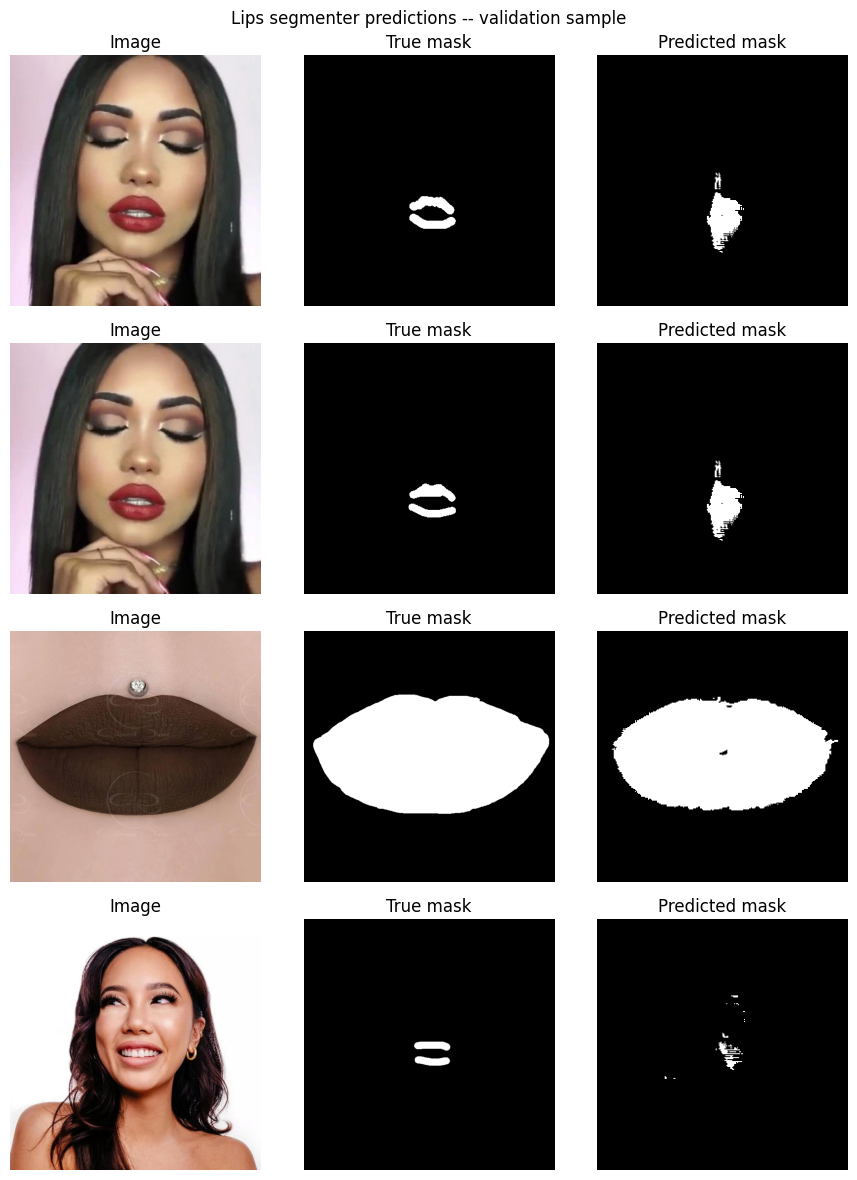

In [27]:
sample_lips = lips_val_df.reset_index(drop=True)
fig, axes = plt.subplots(len(sample_lips), 3, figsize=(9, 3 * len(sample_lips)))
axes = np.array(axes).reshape(len(sample_lips), 3)
for i, row in sample_lips.iterrows():
    img_path = find_image(row['img_name_disk'])
    img = Image.open(img_path).convert('RGB')
    x   = seg_img_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_mask = (torch.sigmoid(seg_lips(x)) > 0.5).squeeze().cpu().numpy()
    true_mask = np.array(Image.open(row['mask_path']).convert('L')) if os.path.exists(row['mask_path']) else np.zeros((img.size[1], img.size[0]))
    axes[i, 0].imshow(img); axes[i, 0].set_title('Image')
    axes[i, 1].imshow(true_mask, cmap='gray'); axes[i, 1].set_title('True mask')
    axes[i, 2].imshow(pred_mask, cmap='gray'); axes[i, 2].set_title('Predicted mask')
    for ax in axes[i]: ax.axis('off')
plt.suptitle('Lips segmenter predictions -- validation sample')
plt.tight_layout()
plt.show()

## 4. Routing & Color Extraction

To isolate segmentation quality from classification errors, routing here uses the **ground-truth label** rather than the classifier's prediction. This way, a bad color prediction can be attributed to the segmenter or extraction strategy alone — not to the classifier sending an image down the wrong path. The end-to-end pipeline using predicted labels is in Section 8.

Extraction per type:
- `bullet` / `liquid` / `pencil` → U-Net mask → **median** LAB from masked pixels
- `closed` → separate U-Net mask → **dominant cluster** LAB from masked pixels
- `swatch` → U-Net mask → **median** LAB from masked pixels
- `lips` → U-Net mask → **median** LAB from masked pixels (18 examples, now with held-out validation — see Stage 2e)

Extraction strategy per type was selected by comparing five strategies in Section 6: median is best for bullet/liquid/pencil/swatch, while dominant cluster outperforms for `closed` (transparent containers where the mask captures a mix of container and color pixels — clustering isolates the true color region).

In [28]:
from sklearn.cluster import KMeans

def extract_swatch_color(img_rgb):
    img_lab = skcolor.rgb2lab(img_rgb / 255.0)
    L = img_lab[:, :, 0]
    fg = (L > 5) & (L < 95)
    if fg.sum() == 0:
        fg = np.ones_like(L, dtype=bool)
    return np.median(img_lab[fg], axis=0)

def extract_masked_color(img_rgb, mask_arr):
    img_lab = skcolor.rgb2lab(img_rgb / 255.0)
    pixels  = img_lab[mask_arr == 1]
    if len(pixels) == 0:
        return np.array([np.nan, np.nan, np.nan])
    return np.median(pixels, axis=0)

def extract_dominant_cluster_color(img_rgb, mask_arr, k=3):
    """LAB centroid of the largest K-means cluster within the masked region.
    Outperforms median for `other` (transparent containers) where the mask
    often captures mixed background pixels alongside the true color region.
    """
    img_lab = skcolor.rgb2lab(img_rgb / 255.0)
    pixels  = img_lab[mask_arr == 1]
    if len(pixels) == 0:
        return np.full(3, np.nan)
    if len(pixels) < k:
        return np.median(pixels, axis=0)
    km = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
    labels = km.fit_predict(pixels)
    biggest = np.bincount(labels).argmax()
    return km.cluster_centers_[biggest]

def predict_mask(model, img_path, device, threshold=0.5):
    img    = Image.open(img_path).convert('RGB')
    orig_w, orig_h = img.size
    x      = seg_img_tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(x)).squeeze().cpu().numpy()
    mask = (prob > threshold).astype(np.uint8)
    return np.array(Image.fromarray(mask * 255).resize((orig_w, orig_h), Image.NEAREST)) // 255

In [29]:
clf.eval()
seg.eval()
seg_other.eval()
seg_swatch.eval()
seg_lips.eval()

results = []
for _, row in labels_df.iterrows():
    if pd.isna(row['img_name_disk']):
        continue
    img_path = find_image(row['img_name_disk'])
    if img_path is None:
        continue
    label = row['label']
    img   = np.array(Image.open(img_path).convert('RGB'))

    if label == 'swatch':
        mask = predict_mask(seg_swatch, img_path, DEVICE)
        lab  = extract_masked_color(img, mask)
    elif label in SEG_CLASSES:
        mask = predict_mask(seg, img_path, DEVICE)
        lab  = extract_masked_color(img, mask)
    elif label == 'closed':  # dominant cluster (best strategy per Section 6)
        mask = predict_mask(seg_other, img_path, DEVICE)
        lab  = extract_dominant_cluster_color(img, mask)
    elif label == 'lips':
        mask = predict_mask(seg_lips, img_path, DEVICE)
        lab  = extract_masked_color(img, mask)
    else:
        lab = np.full(3, np.nan)

    results.append({
        'img_name':      row['img_name'],
        'img_name_disk': row['img_name_disk'],
        'label':         label,
        'pred_L':        lab[0], 'pred_a': lab[1], 'pred_b': lab[2],
        'true_L':        row.get('true_L', np.nan),
        'true_a':        row.get('true_a', np.nan),
        'true_b':        row.get('true_b', np.nan),
    })

predictions = pd.DataFrame(results)
print(predictions.head())
print(f'\n{predictions["pred_L"].notna().sum()} images with extracted color')

                                            img_name  \
0  lipstick__aboutface__paintit_matte_lip_color__...   
1  lipstick__anastasia_beverly_hills__liquid_lips...   
2  lipstick__anastasia_beverly_hills__liquid_lips...   
3  lipstick__anastasia_beverly_hills__matte_lipst...   
4  lipstick__anastasia_beverly_hills__matte_lipst...   

                                       img_name_disk   label     pred_L  \
0  lipstick__aboutface__paintit_matte_lip_color__...  swatch   2.741735   
1  lipstick__anastasia_beverly_hills__liquid_lips...  swatch  57.138888   
2  lipstick__anastasia_beverly_hills__liquid_lips...  liquid  27.909560   
3  lipstick__anastasia_beverly_hills__matte_lipst...  bullet  55.512973   
4  lipstick__anastasia_beverly_hills__matte_lipst...  swatch  62.461104   

      pred_a     pred_b     true_L     true_a     true_b  
0  -0.000174   0.000330   2.677718  -0.000170   0.000322  
1  30.350583  10.889245  42.008854  33.801550  12.567961  
2  -8.213871 -14.011161  27.463101 

## 5. Color Extraction Strategy Comparison & Evaluation

We compare five strategies for summarising the masked pixel distribution into a single LAB value, then score each against ground-truth with Delta E CIE 2000. Lower is better (human threshold ≈ 1–2 JND, commonly cited at 2.3).

177 images evaluated across 5 strategies

=== Overall (sorted by median ΔE) ===
                    n  median ΔE   IQR   Q25   Q75
strategy                                          
median            177       1.36  2.30  0.65  2.95
trimmed_mean_10%  177       1.68  2.62  0.84  3.46
dominant_cluster  177       2.15  3.64  0.86  4.50
shadow_filtered   177       2.24  2.21  1.24  3.45
mean              177       2.58  3.72  1.41  5.12

=== bullet (n=52) ===
                   n  median ΔE   IQR   Q25   Q75
strategy                                         
median            52       1.83  3.46  0.85  4.31
trimmed_mean_10%  52       2.30  3.50  1.03  4.54
shadow_filtered   52       2.59  2.87  1.40  4.27
dominant_cluster  52       3.41  3.70  1.75  5.45
mean              52       3.53  4.30  1.95  6.25

=== closed (n=4) ===
                  n  median ΔE   IQR   Q25   Q75
strategy                                        
dominant_cluster  4       1.65  1.62  1.02  2.65
median            4  

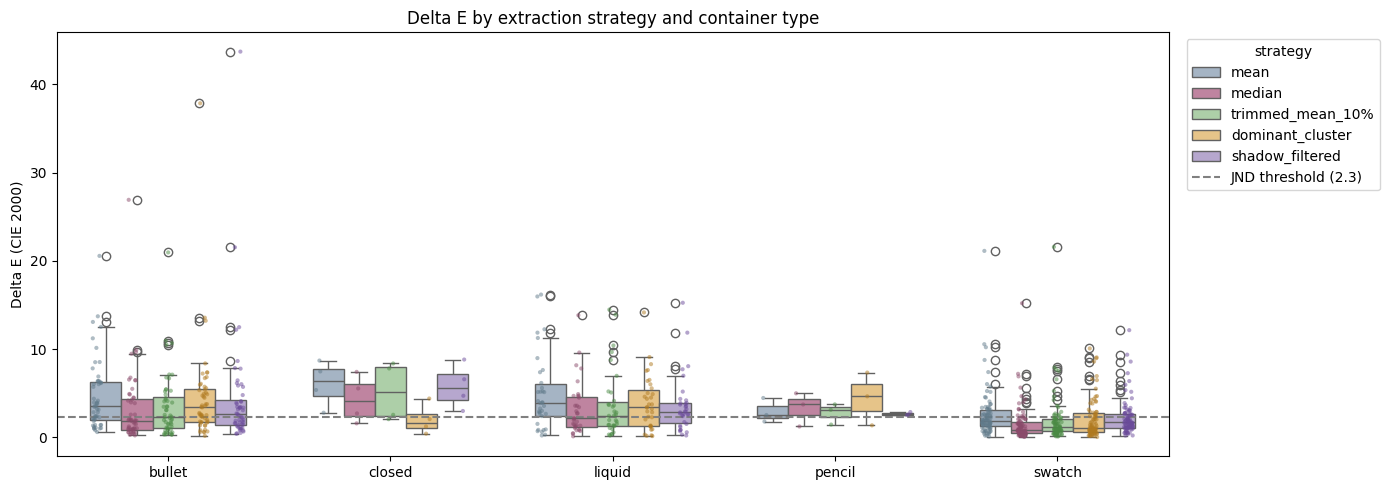

In [30]:
import numpy as np
if not hasattr(np, 'asscalar'):
    np.asscalar = lambda a: a.item()
from colormath.color_objects import LabColor
from colormath.color_diff import delta_e_cie2000
from sklearn.cluster import KMeans

def delta_e(pred_lab, true_lab):
    return delta_e_cie2000(LabColor(*pred_lab), LabColor(*true_lab))

# ── pixel extraction helper ───────────────────────────────────────────────────

def get_masked_lab_pixels(img_rgb, mask):
    lab = skcolor.rgb2lab(img_rgb / 255.0)
    return lab[mask == 1]

# ── strategy functions ────────────────────────────────────────────────────────

def strat_mean(pixels):
    return np.mean(pixels, axis=0)

def strat_median(pixels):
    return np.median(pixels, axis=0)

def strat_trimmed_mean(pixels, trim=0.10):
    L = pixels[:, 0]
    lo, hi = np.quantile(L, trim), np.quantile(L, 1 - trim)
    keep = (L >= lo) & (L <= hi)
    return np.mean(pixels[keep] if keep.sum() > 0 else pixels, axis=0)

def strat_dominant_cluster(pixels, k=3):
    if len(pixels) < k:
        return np.mean(pixels, axis=0)
    km = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
    lbl = km.fit_predict(pixels)
    return km.cluster_centers_[np.bincount(lbl).argmax()]

def strat_shadow_filtered_mean(pixels, chroma_thresh=5.0):
    chroma = np.sqrt(pixels[:, 1] ** 2 + pixels[:, 2] ** 2)
    keep = chroma >= chroma_thresh
    return np.mean(pixels[keep] if keep.sum() > 0 else pixels, axis=0)

STRATEGIES = {
    'mean':              strat_mean,
    'median':            strat_median,
    'trimmed_mean_10%':  strat_trimmed_mean,
    'dominant_cluster':  strat_dominant_cluster,
    'shadow_filtered':   strat_shadow_filtered_mean,
}

# ── run all strategies on every image with ground truth ───────────────────────

seg.eval(); seg_other.eval(); seg_swatch.eval(); seg_lips.eval()

strat_records = []
for _, row in labels_df[labels_df['true_L'].notna() & labels_df['img_name_disk'].notna()].iterrows():
    img_path = find_image(row['img_name_disk'])
    if img_path is None:
        continue
    img_rgb = np.array(Image.open(img_path).convert('RGB'))
    label   = row['label']

    if label == 'swatch':
        mask = predict_mask(seg_swatch, img_path, DEVICE)
    elif label in SEG_CLASSES:
        mask = predict_mask(seg, img_path, DEVICE)
    elif label == 'closed':
        mask = predict_mask(seg_other, img_path, DEVICE)
    elif label == 'lips':
        mask = predict_mask(seg_lips, img_path, DEVICE)
    else:
        continue

    pixels = get_masked_lab_pixels(img_rgb, mask)
    if len(pixels) == 0:
        continue

    rec = {'img_name': row['img_name'], 'label': label,
           'true_L': row['true_L'], 'true_a': row['true_a'], 'true_b': row['true_b']}
    for name, fn in STRATEGIES.items():
        lab = fn(pixels)
        rec[f'{name}_L'], rec[f'{name}_a'], rec[f'{name}_b'] = lab[0], lab[1], lab[2]
    strat_records.append(rec)

strat_df = pd.DataFrame(strat_records)
print(f'{len(strat_df)} images evaluated across {len(STRATEGIES)} strategies')

# ── Delta E per strategy ──────────────────────────────────────────────────────

strategy_names = list(STRATEGIES.keys())
for name in strategy_names:
    strat_df[f'de_{name}'] = strat_df.apply(
        lambda r, n=name: delta_e(
            [r[f'{n}_L'], r[f'{n}_a'], r[f'{n}_b']],
            [r['true_L'],  r['true_a'],  r['true_b']]
        ), axis=1
    )

def strategy_summary(df):
    rows = []
    for name in strategy_names:
        vals = df[f'de_{name}']
        q25, q75 = vals.quantile(0.25), vals.quantile(0.75)
        rows.append({'strategy': name, 'n': len(vals),
                     'median ΔE': vals.median(), 'IQR': q75 - q25,
                     'Q25': q25, 'Q75': q75})
    return pd.DataFrame(rows).set_index('strategy').sort_values('median ΔE')

print('\n=== Overall (sorted by median ΔE) ===')
print(strategy_summary(strat_df).round(2))
for lbl in sorted(strat_df['label'].unique()):
    sub = strat_df[strat_df['label'] == lbl]
    print(f'\n=== {lbl} (n={len(sub)}) ===')
    print(strategy_summary(sub).round(2))

# ── plot ──────────────────────────────────────────────────────────────────────

plot_df = pd.concat([
    strat_df[['label', f'de_{name}']].rename(columns={f'de_{name}': 'delta_e'}).assign(strategy=name)
    for name in strategy_names
], ignore_index=True)

palette_box = {
    'mean':               '#a0b4c9',
    'median':             '#c97aa0',
    'trimmed_mean_10%':   '#a8d5a2',
    'dominant_cluster':   '#f5c87a',
    'shadow_filtered':    '#b5a0d4',
}
palette_strip = {
    'mean':               '#607a8a',
    'median':             '#8a4a6a',
    'trimmed_mean_10%':   '#4a8a44',
    'dominant_cluster':   '#b07a20',
    'shadow_filtered':    '#6a4a9a',
}

order = sorted(strat_df['label'].unique())
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=plot_df, x='label', y='delta_e', hue='strategy',
    order=order, hue_order=strategy_names, palette=palette_box, width=0.7, ax=ax)
sns.stripplot(data=plot_df, x='label', y='delta_e', hue='strategy',
    order=order, hue_order=strategy_names, palette=palette_strip,
    dodge=True, size=3, alpha=0.5, ax=ax, legend=False)
ax.axhline(2.3, color='gray', linestyle='--', label='JND threshold (2.3)')
ax.set_title('Delta E by extraction strategy and container type')
ax.set_xlabel('')
ax.set_ylabel('Delta E (CIE 2000)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(strategy_names) + 1], labels[:len(strategy_names) + 1],
    title='strategy', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ── eval_df: final chosen strategy, used by tier breakdown below ──────────────
# median for bullet / liquid / swatch; dominant cluster for closed

eval_df = predictions.dropna(subset=['true_L', 'pred_L']).copy()
eval_df['delta_e'] = eval_df.apply(
    lambda r: delta_e(
        [r['pred_L'], r['pred_a'], r['pred_b']],
        [r['true_L'], r['true_a'], r['true_b']]
    ), axis=1
)


Delta E CIE 2000 — tier breakdown by container type (median strategy)



,n,≤ 2.3 (great),2.3 – 5 (acceptable),> 5 (poor)
category,,,,
bullet,52,33 (63%),10 (19%),9 (17%)
closed,4,3 (75%),1 (25%),0 (0%)
liquid,34,18 (53%),11 (32%),5 (15%)
pencil,3,1 (33%),2 (67%),0 (0%)
swatch,84,70 (83%),10 (12%),4 (5%)
ALL,177,125 (71%),34 (19%),18 (10%)


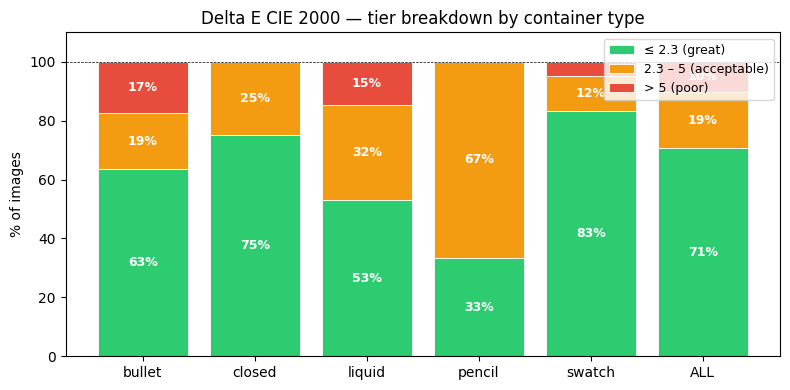

In [31]:
# Delta E tier breakdown per container type
# Three tiers: ≤2.3 (great — within JND), 2.3–5 (acceptable), >5 (poor)

def tier_breakdown(df, group_col='label', de_col='delta_e'):
    rows = []
    for label, grp in df.groupby(group_col):
        n = len(grp)
        great      = (grp[de_col] <= 2.3).sum()
        acceptable = ((grp[de_col] > 2.3) & (grp[de_col] <= 5)).sum()
        poor       = (grp[de_col] > 5).sum()
        rows.append({
            'category':           label,
            'n':                  n,
            '≤ 2.3 (great)':      f"{great} ({100*great/n:.0f}%)",
            '2.3 – 5 (acceptable)': f"{acceptable} ({100*acceptable/n:.0f}%)",
            '> 5 (poor)':         f"{poor} ({100*poor/n:.0f}%)",
            '_great_pct':         100 * great / n,
            '_ok_pct':            100 * acceptable / n,
            '_poor_pct':          100 * poor / n,
        })
    # Overall row
    n = len(df)
    great      = (df[de_col] <= 2.3).sum()
    acceptable = ((df[de_col] > 2.3) & (df[de_col] <= 5)).sum()
    poor       = (df[de_col] > 5).sum()
    rows.append({
        'category':           'ALL',
        'n':                  n,
        '≤ 2.3 (great)':      f"{great} ({100*great/n:.0f}%)",
        '2.3 – 5 (acceptable)': f"{acceptable} ({100*acceptable/n:.0f}%)",
        '> 5 (poor)':         f"{poor} ({100*poor/n:.0f}%)",
        '_great_pct':         100 * great / n,
        '_ok_pct':            100 * acceptable / n,
        '_poor_pct':          100 * poor / n,
    })
    return pd.DataFrame(rows)

bd = tier_breakdown(eval_df)
display_cols = ['category', 'n', '≤ 2.3 (great)', '2.3 – 5 (acceptable)', '> 5 (poor)']
print("Delta E CIE 2000 — tier breakdown by container type (median strategy)\n")
display(bd[display_cols].set_index('category'))

# Stacked bar chart
categories = bd['category'].tolist()
pct_great  = bd['_great_pct'].values
pct_ok     = bd['_ok_pct'].values
pct_poor   = bd['_poor_pct'].values

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
labels_tiers = ['≤ 2.3 (great)', '2.3 – 5 (acceptable)', '> 5 (poor)']
bottoms = np.zeros(len(categories))
for pct, color, tier_label in zip([pct_great, pct_ok, pct_poor], colors, labels_tiers):
    bars = ax.bar(categories, pct, bottom=bottoms, color=color,
                  label=tier_label, edgecolor='white', linewidth=0.6)
    for bar, val in zip(bars, pct):
        if val >= 7:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.0f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottoms += pct

ax.set_ylabel('% of images')
ax.set_ylim(0, 110)
ax.set_title('Delta E CIE 2000 — tier breakdown by container type')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(100, color='black', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()


The worst cases per container type are shown below (top 3 by Delta E within each category). For each image, the predicted mask region is highlighted and the predicted color swatch (left) is placed next to the ground-truth color (right).

**Note:** because Section 4 routes images using ground-truth labels, classifier misclassification errors — e.g. a `closed` container routed to the bullet/liquid segmenter — cannot appear here. Those failures are visible in the end-to-end evaluation in Section 7. Swatches tend to dominate global top-N rankings because shadow gradients and color depth variation inflate their Delta E systematically; stratifying by category avoids this.

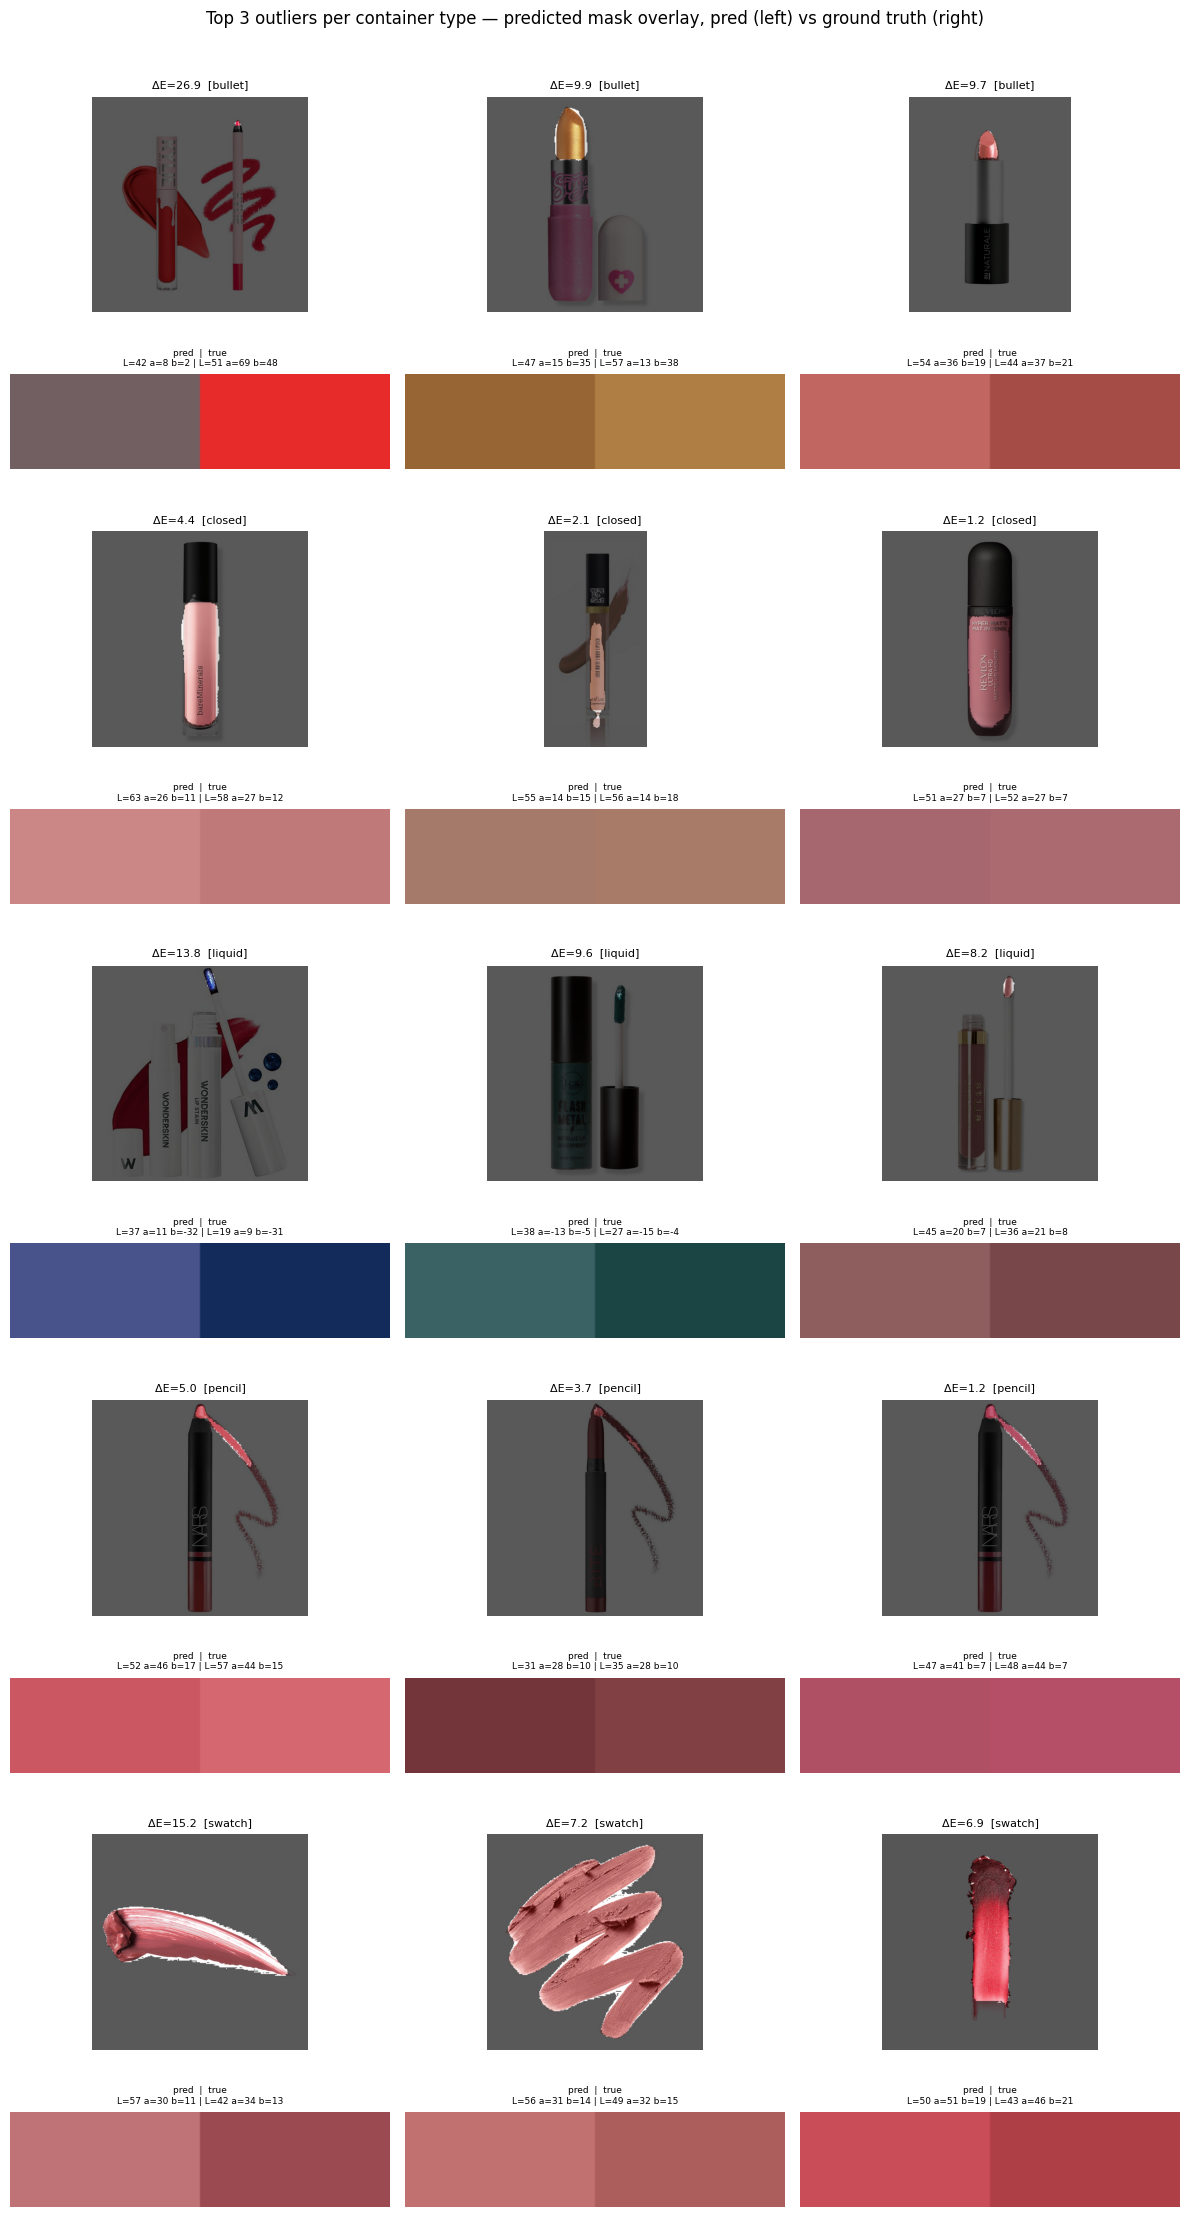

In [32]:
def lab_to_rgb_swatch(L, a, b, size=(80, 40)):
    lab = np.array([[[L, a, b]]], dtype=np.float64)
    rgb = skcolor.lab2rgb(lab).clip(0, 1)
    swatch = np.ones((size[1], size[0], 3), dtype=np.float32) * rgb[0, 0]
    return swatch

# Top 3 worst cases per category (stratified — avoids swatches dominating)
n_per_cat = 3
outliers = (
    eval_df
    .sort_values('delta_e', ascending=False)
    .groupby('label', group_keys=False)
    .head(n_per_cat)
    .reset_index(drop=True)
)
# Sort for display: group by category, worst first within each
outliers = outliers.sort_values(['label', 'delta_e'], ascending=[True, False]).reset_index(drop=True)

n_show = len(outliers)
ncols = n_per_cat
nrows = len(outliers['label'].unique())
fig, axes = plt.subplots(nrows * 2, ncols, figsize=(ncols * 4, nrows * 4.5))
axes = axes.reshape(nrows * 2, ncols)

clf.eval(); seg.eval(); seg_other.eval(); seg_swatch.eval()

cat_order = sorted(outliers['label'].unique())
for cat_idx, cat in enumerate(cat_order):
    cat_rows = outliers[outliers['label'] == cat].reset_index(drop=True)
    for col_idx, (_, row) in enumerate(cat_rows.iterrows()):
        r = cat_idx * 2
        c = col_idx

        ax_img = axes[r, c]
        img_path = find_image(row['img_name_disk'])
        img = np.array(Image.open(img_path).convert('RGB'))

        label = row['label']
        if label == 'swatch':
            mask = predict_mask(seg_swatch, img_path, DEVICE)
        elif label in SEG_CLASSES:
            mask = predict_mask(seg, img_path, DEVICE)
        else:
            mask = predict_mask(seg_other, img_path, DEVICE)

        overlay = img.copy().astype(float)
        overlay[mask == 0] *= 0.35
        ax_img.imshow(overlay.astype(np.uint8))
        ax_img.set_title(f"ΔE={row['delta_e']:.1f}  [{label}]", fontsize=8)
        ax_img.axis('off')

        ax_color = axes[r + 1, c]
        pred_sw = lab_to_rgb_swatch(row['pred_L'], row['pred_a'], row['pred_b'])
        true_sw = lab_to_rgb_swatch(row['true_L'], row['true_a'], row['true_b'])
        ax_color.imshow(np.concatenate([pred_sw, true_sw], axis=1))
        ax_color.set_title(
            f"pred  |  true\n"
            f"L={row['pred_L']:.0f} a={row['pred_a']:.0f} b={row['pred_b']:.0f} | "
            f"L={row['true_L']:.0f} a={row['true_a']:.0f} b={row['true_b']:.0f}",
            fontsize=6.5
        )
        ax_color.axis('off')

    # blank out unused columns if a category has fewer than n_per_cat
    for col_idx in range(len(cat_rows), ncols):
        axes[cat_idx * 2, col_idx].axis('off')
        axes[cat_idx * 2 + 1, col_idx].axis('off')

plt.suptitle(
    f'Top {n_per_cat} outliers per container type — predicted mask overlay, pred (left) vs ground truth (right)',
    y=1.01
)
plt.tight_layout()
plt.show()


**Strategy conclusions:**

Across `bullet`, `liquid`, and `swatch`, **median** extraction consistently achieves the lowest median Delta E and tightest spread. `pencil` (n=3) also does best under median, though its ΔE (~3, with an enormous spread across just 3 ground-truth examples) is noisy and, on the worst examples, notably worse than the established classes -- though its combined segmenter has now seen 27 pencil examples. `lips` doesn't appear in this comparison at all: none of the 18 `lips` images have ground-truth CIELAB yet (that's a separate manual annotation step in notebook 04, not done for this round), so its bootstrap segmenter's extraction quality is still unverified. For `closed` (transparent containers), `dominant_cluster` appears better (clustering could be avoiding the dark container body that biases simple pixel statistics), but with only 4 annotated images this difference is not conclusive. The pipeline uses **median** for all container types except `closed`, where **dominant cluster** is applied.

Because of the category imbalance, rather than improving the segmentation model, I will focus on active learning for the classifier, which should improve the `closed` category classification and a result, segmentation. 

## 6. Diagnosing Stage 1 Misclassification → Active Learning for the Classifier

The outliers in Section 5 point to a Stage 1 problem: `closed`-container images are being misclassified as `bullet` or `liquid`, which routes them through the wrong U-Net and produces a nonsense color prediction.

**Step 1** surfaces this by scoring classifier uncertainty on images outside the training set. Low-confidence predictions — especially images the model splits between `bullet`/`liquid` and `closed` — reveal the misclassification pattern.

**Step 2** uses those images as an annotation queue: review, correct the label where wrong, and retrain Stage 1 with the expanded dataset.

In [33]:
# ── Find images outside classifier training/val sets ────────────────────────
clf_known = set(train_df['img_name_disk'].dropna()) | set(val_df['img_name_disk'].dropna())

all_on_disk = {}
for d in IMG_DIRS:
    for fname in os.listdir(d):
        if fname not in all_on_disk:
            all_on_disk[fname] = os.path.join(d, fname)

pool_candidates = [
    {'img_name': name, 'img_path': path}
    for name, path in all_on_disk.items()
    if name not in clf_known
]
print(f'Pool: {len(pool_candidates)} images outside classifier training/val sets')

# ── Score classifier uncertainty and record class probabilities ──────────────
def score_clf_uncertainty(model, img_path, device):
    """Returns (predicted_class, confidence, full softmax prob array)."""
    img = Image.open(img_path).convert('RGB')
    with torch.no_grad():
        probs = torch.softmax(
            model(val_tf(img).unsqueeze(0).to(device)), dim=1
        ).squeeze().cpu().numpy()
    return CLASSES[probs.argmax()], float(probs.max()), probs

clf.eval()
scored = []
for item in pool_candidates:
    try:
        pred_label, conf, probs = score_clf_uncertainty(clf, item['img_path'], DEVICE)
        scored.append({
            **item,
            'pred_label':  pred_label,
            'confidence':  conf,
            'uncertainty': 1 - conf,
            **{f'p_{c}': float(p) for c, p in zip(CLASSES, probs)},
        })
    except Exception:
        continue

pool_clf_df = (
    pd.DataFrame(scored)
    .sort_values('uncertainty', ascending=False)
    .reset_index(drop=True)
)
print(f'\nTop 10 most uncertain classifier predictions:')
print(pool_clf_df[['img_name', 'pred_label', 'confidence']].head(10).to_string(index=False))


Pool: 61 images outside classifier training/val sets



Top 10 most uncertain classifier predictions:
                                                                                             img_name pred_label  confidence
             lipstick__nyx_professional_makeup__fat_oil_slick_click_vegan_lip_balm__13_going_live.jpg     closed    0.363882
         lipstick__chanel__le_rouge_duo_ultra_tenue_ultrawear_liquid_lip_colour__59_shocking_pink.jpg     swatch    0.697646
     lipstick__chanel__le_rouge_duo_ultra_tenue_ultrawear_liquid_lip_colour__104_bright_raspberry.jpg     swatch    0.718022
          lipstick__chanel__le_rouge_duo_ultra_tenue_ultrawear_liquid_lip_colour__172_light_mauve.jpg     swatch    0.775070
            lipstick__chanel__le_rouge_duo_ultra_tenue_ultrawear_liquid_lip_colour__40_light_rose.jpg     swatch    0.775906
lipstick__valentino__rosso_valentino_high_pigment_refillable_lipstick__190r_walk_on_the_wild_side.jpg     swatch    0.862102
          lipstick__chanel__le_rouge_duo_ultra_tenue_ultrawear_liquid_lip_colo

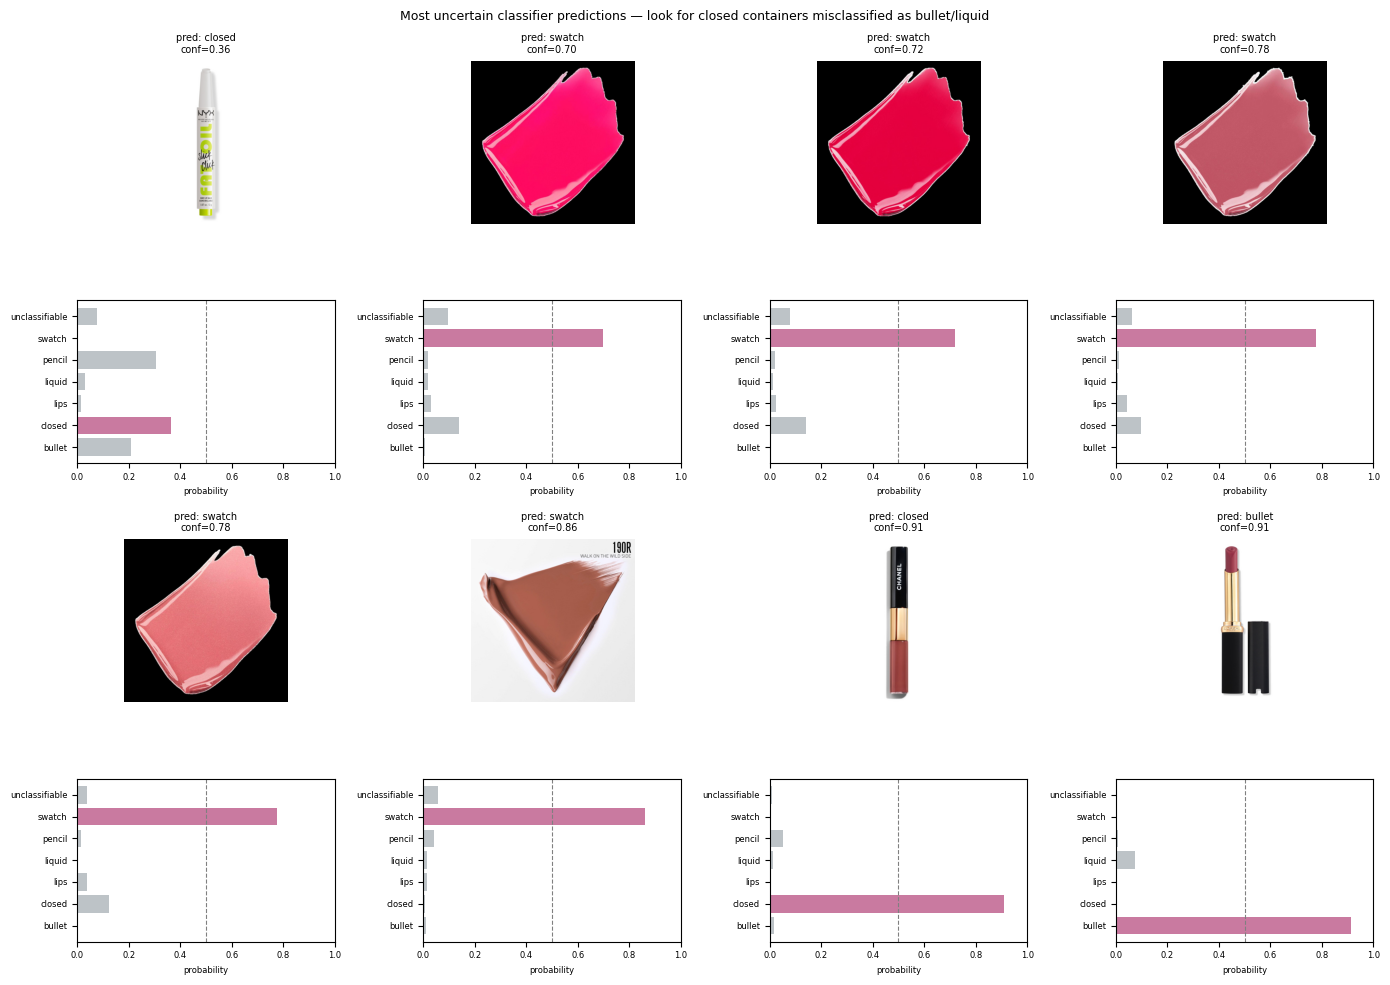

In [34]:
n_show = min(8, len(pool_clf_df))
if n_show == 0:
    print('Pool is empty — all images in IMG_DIRS are already in the classifier training/val sets.')
else:
    top = pool_clf_df.head(n_show).reset_index(drop=True)
    ncols = 4
    nrows = int(np.ceil(n_show / ncols))
    fig, axes = plt.subplots(nrows * 2, ncols, figsize=(ncols * 3.5, nrows * 5))
    axes = axes.reshape(nrows * 2, ncols)

    for i, row in top.iterrows():
        r, c = (i // ncols) * 2, i % ncols
        img = np.array(Image.open(row['img_path']).convert('RGB'))
        axes[r, c].imshow(img)
        axes[r, c].set_title(
            f"pred: {row['pred_label']}\nconf={row['confidence']:.2f}", fontsize=7
        )
        axes[r, c].axis('off')

        probs = [row[f'p_{cls}'] for cls in CLASSES]
        bar_colors = ['#c97aa0' if CLASSES[j] == row['pred_label'] else '#bdc3c7'
                      for j in range(len(CLASSES))]
        axes[r+1, c].barh(CLASSES, probs, color=bar_colors)
        axes[r+1, c].set_xlim(0, 1)
        axes[r+1, c].axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
        axes[r+1, c].tick_params(labelsize=6)
        axes[r+1, c].set_xlabel('probability', fontsize=6)

    for j in range(n_show, nrows * ncols):
        r, c = (j // ncols) * 2, j % ncols
        axes[r, c].axis('off')
        axes[r+1, c].axis('off')

    plt.suptitle(
        'Most uncertain classifier predictions — look for closed containers misclassified as bullet/liquid',
        fontsize=9
    )
    plt.tight_layout()
    plt.show()


In [35]:
export_path = os.path.join(ANN_DIR, 'active_learning_queue.csv')
pool_clf_df[['img_name', 'img_path', 'pred_label', 'confidence', 'uncertainty']].to_csv(export_path, index=False)
print(f'Exported {len(pool_clf_df)} candidates → {export_path}')
print('Review these images and add a "correct_label" column where the prediction is wrong.')


Exported 61 candidates → /Users/connie/dev/lipstick_color_extraction/data/annotations/active_learning_queue.csv
Review these images and add a "correct_label" column where the prediction is wrong.


### Step 2: Correct labels and retrain Stage 1

1. Open `data/annotations/active_learning_queue.csv`: prioritize images with the lowest confidence
2. Add a `correct_label` column with the true container type: `bullet`, `liquid`, `swatch`, or `closed`
3. Run the retrain cell below: it merges the corrected labels with the existing training set, recalculates class weights, and retrains Stage 1

No mask drawing needed: this is label correction only.

In [36]:
NEW_LABELS = os.path.join(ANN_DIR, 'active_learning_queue.csv')

_queue = pd.read_csv(NEW_LABELS) if os.path.exists(NEW_LABELS) else None
_has_corrections = _queue is not None and 'correct_label' in _queue.columns and _queue['correct_label'].notna().any()

if not _has_corrections:
    print('No corrected labels yet in the exported queue.')
    print(f'Review {NEW_LABELS}, add a "correct_label" column, and re-run this cell.')
    # No corrections to fine-tune on yet -- keep using the Phase 1 classifier and its val split
    # so downstream cells (evaluation, end-to-end comparison) still have something to run on.
    # Still write resnet18_classifier_al.pth: notebooks 07/08 load this file specifically, and
    # leaving a stale checkpoint there (wrong class order) is exactly the class-order-drift bug
    # this project has been burned by before.
    clf_al = clf
    val2   = val_df
    ckpt_al = os.path.join(MODELS_DIR, 'resnet18_classifier_al.pth')
    torch.save({'model_state_dict': clf_al.state_dict(), 'classes': CLASSES}, ckpt_al)
    print(f'Wrote {ckpt_al} as a copy of the Phase 1 classifier (no fine-tune happened yet).')
else:
    new_labels = (
        _queue
        .pipe(lambda d: d[d['correct_label'].notna()])
        .rename(columns={'correct_label': 'label'})
    )
    # img_name in this file is already the disk filename (from os.listdir)
    new_labels['img_name_disk'] = new_labels['img_name']
    # remap old label names to current label convention
    label_remap = {'other': 'closed', 'liquid_lipstick': 'liquid', 'bullet_lipstick': 'bullet'}
    new_labels['label'] = new_labels['label'].replace(label_remap)
    print(f'{len(new_labels)} corrected labels loaded')
    print(new_labels['label'].value_counts().to_string())

    # ── Expand dataset (original + corrected) ──────────────────────────────
    clf_all = pd.concat([
        labels_df[['img_name', 'img_name_disk', 'label']],
        new_labels[['img_name', 'img_name_disk', 'label']]
    ], ignore_index=True).drop_duplicates(subset='img_name_disk')

    counts2 = clf_all['label'].value_counts()
    total2  = len(clf_all)
    cw2 = torch.tensor(
        [total2 / (len(CLASSES) * counts2.get(c, 1)) for c in CLASSES], dtype=torch.float
    )
    print('Updated class weights:', {c: round(w, 3) for c, w in zip(CLASSES, cw2.tolist())})

    ann_closed2 = set(os.listdir(IMG_CLOSED))
    force2      = clf_all[clf_all['img_name_disk'].isin(ann_closed2)]
    to_split2   = clf_all[~clf_all['img_name_disk'].isin(ann_closed2) & clf_all['img_name_disk'].notna()]
    rest2, val2 = train_test_split(to_split2, test_size=0.2, stratify=to_split2['label'], random_state=42)
    train2      = pd.concat([force2, rest2]).reset_index(drop=True)
    print(f'Expanded — train: {len(train2)}  val: {len(val2)}  (was: {len(train_df)} / {len(val_df)})')

    # ── Fine-tune the existing classifier (don't retrain from scratch) ──────
    clf_al = build_classifier(num_classes=len(CLASSES), pretrained=False).to(DEVICE)
    clf_al.load_state_dict(torch.load(clf_ckpt, map_location=DEVICE)['model_state_dict'])

    ckpt_al   = os.path.join(MODELS_DIR, 'resnet18_classifier_al.pth')
    crit_al   = nn.CrossEntropyLoss(weight=cw2.to(DEVICE))
    tr_loader = DataLoader(ProductDataset(train2, train_tf), batch_size=32, shuffle=True, num_workers=0)
    va_loader = DataLoader(ProductDataset(val2,   val_tf),   batch_size=32, num_workers=0)

    for p in clf_al.parameters(): p.requires_grad = True
    opt_al   = torch.optim.Adam(clf_al.parameters(), lr=1e-5)
    sched_al = torch.optim.lr_scheduler.StepLR(opt_al, step_size=5, gamma=0.1)
    best_va  = 0.0
    print('Fine-tuning on expanded dataset (10 epochs, lr=1e-5)')
    for epoch in range(10):
        _, tr = run_epoch(clf_al, tr_loader, crit_al, opt_al, DEVICE)
        _, va = run_epoch(clf_al, va_loader, crit_al, opt_al, DEVICE, train=False)
        sched_al.step()
        print(f'  {epoch+1:2d}: train={tr:.3f}  val={va:.3f}')
        if va > best_va:
            best_va = va
            torch.save({'model_state_dict': clf_al.state_dict(), 'classes': CLASSES}, ckpt_al)

    print(f'\nBest val acc: {best_va:.3f}  →  {ckpt_al}')
    clf = clf_al
    print('Global `clf` updated to fine-tuned classifier.')


No corrected labels yet in the exported queue.
Review /Users/connie/dev/lipstick_color_extraction/data/annotations/active_learning_queue.csv, add a "correct_label" column, and re-run this cell.
Wrote /Users/connie/dev/lipstick_color_extraction/models/resnet18_classifier_al.pth as a copy of the Phase 1 classifier (no fine-tune happened yet).


                precision    recall  f1-score   support

        bullet       1.00      0.87      0.93        15
        closed       0.50      0.50      0.50         2
          lips       1.00      1.00      1.00         3
        liquid       1.00      1.00      1.00         9
        pencil       0.83      1.00      0.91         5
        swatch       1.00      1.00      1.00        21
unclassifiable       0.80      1.00      0.89         4

      accuracy                           0.95        59
     macro avg       0.88      0.91      0.89        59
  weighted avg       0.96      0.95      0.95        59



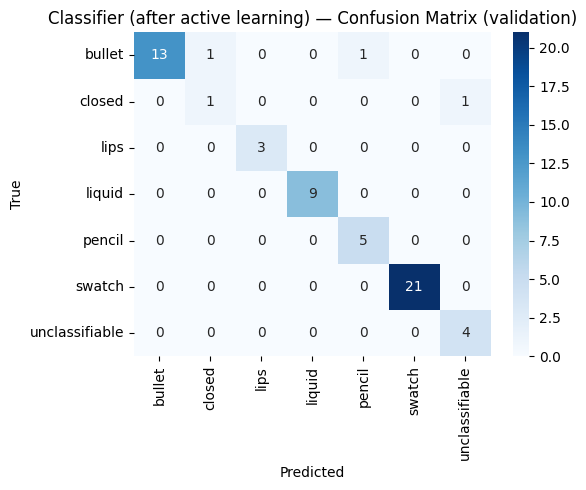

In [37]:
# Evaluate fine-tuned classifier on the expanded validation set
clf.eval()
preds_al, targets_al = [], []
with torch.no_grad():
    for x, y in DataLoader(ProductDataset(val2, val_tf), batch_size=32):
        preds_al.extend(clf(x.to(DEVICE)).argmax(1).cpu().tolist())
        targets_al.extend(y.tolist())

print(classification_report(targets_al, preds_al, target_names=CLASSES))

cm_al = confusion_matrix(targets_al, preds_al)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_al, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES,
            cmap='Blues', ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Classifier (after active learning) — Confusion Matrix (validation)')
plt.tight_layout()
plt.show()


### Step 3: What active learning actually improved

The routing accuracy table below compares the original classifier against whatever Step 2 produced. **In this run, Step 2 had no corrected labels to fine-tune on** (`active_learning_queue.csv` was freshly exported and hasn't been reviewed yet), so it fell back to the Phase 1 classifier unchanged -- "original" and "fine-tuned" are the same model here, which is why the table below shows identical numbers for every class. That's expected, not a bug: real gains only show up after the queue is reviewed (add a `correct_label` column) and this section is re-run.

When corrections do exist, the improvement isn't visible in this table either way, because `labels_df` is the classifier's own training/validation set -- the real test is generalization to images the model has never seen, which isn't captured by Delta E since pool labels are container type only, not color.

In [38]:
def run_e2e(classifier):
    """Run full pipeline using classifier predictions for routing."""
    classifier.eval(); seg.eval(); seg_other.eval(); seg_swatch.eval(); seg_lips.eval()
    rows = []
    for _, row in labels_df.iterrows():
        if pd.isna(row['img_name_disk']):
            continue
        img_path = find_image(row['img_name_disk'])
        if img_path is None:
            continue
        pred_label, conf, _ = score_clf_uncertainty(classifier, img_path, DEVICE)
        if conf < CLF_THRESHOLD:
            pred_label = 'color_not_shown'
        img = np.array(Image.open(img_path).convert('RGB'))
        if pred_label == 'swatch':
            mask = predict_mask(seg_swatch, img_path, DEVICE)
            lab  = extract_masked_color(img, mask)
        elif pred_label in SEG_CLASSES:
            mask = predict_mask(seg, img_path, DEVICE)
            lab  = extract_masked_color(img, mask)
        elif pred_label == 'closed':
            mask = predict_mask(seg_other, img_path, DEVICE)
            lab  = extract_dominant_cluster_color(img, mask)
        elif pred_label == 'lips':
            mask = predict_mask(seg_lips, img_path, DEVICE)
            lab  = extract_masked_color(img, mask)
        else:  # unclassifiable, or a below-threshold fallback for any other prediction
            lab  = np.full(3, np.nan)
        rows.append({
            'img_name':         row['img_name'],
            'true_label':       row['label'],
            'pred_label':       pred_label,
            'routed_correctly': row['label'] == pred_label,
        })
    return pd.DataFrame(rows)

# ── Run both classifiers ──────────────────────────────────────────────────────
clf_orig = build_classifier(num_classes=len(CLASSES), pretrained=False).to(DEVICE)
clf_orig.load_state_dict(torch.load(clf_ckpt, map_location=DEVICE)['model_state_dict'])

e2e_orig_df = run_e2e(clf_orig)
e2e_al_df   = run_e2e(clf)

# ── Routing accuracy table ────────────────────────────────────────────────────
acc_rows = []
for cls in CLASSES:
    orig_cls     = e2e_orig_df[e2e_orig_df['true_label'] == cls]
    al_cls       = e2e_al_df[e2e_al_df['true_label'] == cls]
    n_wrong_orig = (~orig_cls['routed_correctly']).sum()
    n_wrong_al   = (~al_cls['routed_correctly']).sum()
    acc_rows.append({
        'class':      cls,
        'n':          len(orig_cls),
        'original':   f"{orig_cls['routed_correctly'].mean():.0%}  ({n_wrong_orig} wrong)",
        'fine-tuned': f"{al_cls['routed_correctly'].mean():.0%}  ({n_wrong_al} wrong)",
    })

acc_tbl = pd.DataFrame(acc_rows).set_index('class')
print('Routing accuracy on labeled images (train + val — not a held-out test)\n')
print(acc_tbl.to_string())
print(f'\nOverall — original: {e2e_orig_df["routed_correctly"].mean():.1%}   '
      f'fine-tuned: {e2e_al_df["routed_correctly"].mean():.1%}')
print('\nBoth classifiers are near-perfect here because these are training/val images.')
if _has_corrections:
    print('Active learning fine-tuned on the corrected pool to improve generalization to unseen')
    print('images. That gain cannot be evaluated for Delta E since pool labels are container type')
    print('only, not color.')
else:
    print('No corrected labels were available this run, so "fine-tuned" is the same model as')
    print('"original" -- Section 6 Step 2 fell back to the Phase 1 classifier. Review the exported')
    print('queue and re-run Step 2 to actually fine-tune.')

Routing accuracy on labeled images (train + val — not a held-out test)

                  n         original       fine-tuned
class                                                
bullet           73   97%  (2 wrong)   97%  (2 wrong)
closed           21   95%  (1 wrong)   95%  (1 wrong)
lips             16  100%  (0 wrong)  100%  (0 wrong)
liquid           49  100%  (0 wrong)  100%  (0 wrong)
pencil           27  100%  (0 wrong)  100%  (0 wrong)
swatch          107  100%  (0 wrong)  100%  (0 wrong)
unclassifiable   18   89%  (2 wrong)   89%  (2 wrong)

Overall — original: 98.4%   fine-tuned: 98.4%

Both classifiers are near-perfect here because these are training/val images.
No corrected labels were available this run, so "fine-tuned" is the same model as
"original" -- Section 6 Step 2 fell back to the Phase 1 classifier. Review the exported
queue and re-run Step 2 to actually fine-tune.


## 7. Active Learning Part 2 — Segmentation Mask Annotation

The classifier active learning loop in Section 6 improved routing accuracy, but segmenter quality is bounded by the number of annotated masks. To grow the mask dataset efficiently we apply active learning to the segmenters: score each unlabeled image by mask uncertainty (mean pixel-level entropy in the sigmoid output) and prioritize the most uncertain images for mask annotation in Label Studio.

**Swatch is excluded.** The swatch segmenter is already at IoU 0.93 and does not need more data. The pool covers **bullet**, **liquid**, **pencil** (combined segmenter), **closed**, and **lips**. `lips` is prioritized highest again -- the pencil/crayon keyword-oversampling round (notebook 03 Strategy 4, notebook 05 Round 5) grew `pencil` from 9 to 28 as a side effect, while `lips` slipped slightly (19 to 18, one image was relabeled to `pencil`) and is now the scarcer of the two.

**Why filter by classifier confidence?** There are two different kinds of uncertainty at play here. In Part 1, we wanted images where the *classifier* was uncertain — low confidence meant the model did not know which product type it was looking at, so a corrected label would be most informative. Here in Part 2, we are trying to improve the *segmenters*, not the classifier. To annotate a segmentation mask, you need to know what type the image is — otherwise you would not know which region to draw. So we only queue images where the classifier is already confident (above `CLF_THRESHOLD = 0.6`), and then rank those by how uncertain the *segmenter* is about the mask boundary. Images where the classifier is still uncertain belong back in the Part 1 queue, not here.

### Step 1: Score unlabeled images by segmenter uncertainty

In [39]:
# Images already in labels_df have masks; everything else is the pool
labeled_disk = set(labels_df['img_name_disk'].dropna())
pool = []
for d in IMG_DIRS:
    if not os.path.isdir(d):
        continue
    for f in os.listdir(d):
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')) and f not in labeled_disk:
            pool.append((f, os.path.join(d, f)))

print(f'{len(pool)} images without mask annotations')

# Only score types where more annotations are needed; swatch is excluded (IoU 0.93)
SCORE_LABELS = {'bullet', 'liquid', 'pencil', 'closed', 'lips'}

clf.eval(); seg.eval(); seg_other.eval(); seg_lips.eval()

def mask_uncertainty(model, img_path):
    """Mean pixel entropy of sigmoid output — higher = more uncertain."""
    img = Image.open(img_path).convert('RGB')
    x = seg_img_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        p = torch.sigmoid(model(x)).squeeze().cpu().numpy()
    eps = 1e-6
    return float((-(p * np.log(p + eps) + (1 - p) * np.log(1 - p + eps))).mean())

rows = []
for img_name, img_path in pool:
    try:
        x = val_tf(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            probs = torch.softmax(clf(x), dim=1).squeeze().cpu().numpy()
        pred_label = CLASSES[probs.argmax()]
        confidence = float(probs.max())
        if confidence < CLF_THRESHOLD or pred_label not in SCORE_LABELS:
            continue

        if pred_label in SEG_CLASSES:
            unc = mask_uncertainty(seg, img_path)
        elif pred_label == 'closed':
            unc = mask_uncertainty(seg_other, img_path)
        else:  # lips
            unc = mask_uncertainty(seg_lips, img_path)

        rows.append({
            'img_name':        img_name,
            'img_path':        img_path,
            'pred_label':      pred_label,
            'clf_confidence':  round(confidence, 3),
            'seg_uncertainty': round(unc, 4),
        })
    except Exception:
        continue

pool_seg_df = pd.DataFrame(rows)
print(pool_seg_df.groupby('pred_label')[['seg_uncertainty']].describe().round(3))
pool_seg_df.sort_values('seg_uncertainty', ascending=False).head(10)


63 images without mask annotations


           seg_uncertainty                                                 
                     count   mean    std    min    25%    50%    75%    max
pred_label                                                                 
bullet                 5.0  0.491  0.006  0.481  0.491  0.492  0.495  0.495
closed                26.0  0.433  0.004  0.419  0.432  0.433  0.435  0.437
liquid                10.0  0.492  0.007  0.483  0.486  0.493  0.498  0.501
pencil                 1.0  0.489    NaN  0.489  0.489  0.489  0.489  0.489


,img_name,img_path,pred_label,clf_confidence,seg_uncertainty
6,lipstick__covergirl__outlast_forever_velvet_pi...,/Users/connie/dev/lipstick_color_extraction/da...,liquid,0.991,0.5010
16,lipstick__nyx_professional_makeup__lip_lingeri...,/Users/connie/dev/lipstick_color_extraction/da...,liquid,0.985,0.4982
5,lipstick__nyx_professional_makeup__lip_lingeri...,/Users/connie/dev/lipstick_color_extraction/da...,liquid,0.994,0.4981
0,lipstick__nyx_professional_makeup__lip_lingeri...,/Users/connie/dev/lipstick_color_extraction/da...,liquid,0.993,0.4975
9,lipstick__lancome__lip_idole_squalane12_butter...,/Users/connie/dev/lipstick_color_extraction/da...,bullet,0.958,0.4952
3,lipstick__loreal__colour_riche_intense_volume_...,/Users/connie/dev/lipstick_color_extraction/da...,bullet,0.913,0.4946
4,lipstick__onesize_by_patrick_starrr__lip_snatc...,/Users/connie/dev/lipstick_color_extraction/da...,liquid,0.945,0.4942
10,lipstick__yves_saint_laurent__rouge_volupte_sh...,/Users/connie/dev/lipstick_color_extraction/da...,bullet,0.989,0.4925
35,lipstick__bareminerals__gen_nude_matte_liquid_...,/Users/connie/dev/lipstick_color_extraction/da...,liquid,0.999,0.4924
7,lipstick__nyx_professional_makeup__liquid_sued...,/Users/connie/dev/lipstick_color_extraction/da...,liquid,0.957,0.4919


### Step 2: Export prioritized queue for Label Studio

Images are ranked by segmenter uncertainty within each priority tier (`bullet`/`liquid` first, then `closed`, then `swatch`). Import the exported CSV into Label Studio and draw masks starting from the top.

After annotating and exporting a new Label Studio JSON save the export to `data/processed/`


In [40]:
priority_order = {'lips': 1, 'bullet': 2, 'liquid': 2, 'pencil': 2, 'closed': 3}
pool_seg_df['priority'] = pool_seg_df['pred_label'].map(priority_order)

export_seg_path = os.path.join(ANN_DIR, 'active_learning_seg_queue.csv')
(pool_seg_df
    .sort_values(['priority', 'seg_uncertainty'], ascending=[True, False])
    .drop(columns='priority')
    .to_csv(export_seg_path, index=False))

print(f'Exported {len(pool_seg_df)} images → {export_seg_path}')
print(pool_seg_df['pred_label'].value_counts().rename('count'))


Exported 42 images → /Users/connie/dev/lipstick_color_extraction/data/annotations/active_learning_seg_queue.csv
pred_label
closed    26
liquid    10
bullet     5
pencil     1
Name: count, dtype: int64
